In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 27 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 27.05 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149145 entries, 0 to 149144
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 490.4+ MB
None


In [4]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, opp_team_name, opp_team_elo, total_points, minutes, goals_scored
                            FROM playergw_transformed
                        WHERE season = 20252026 
                          AND event = 26 
                          AND player_name_id = 'Bukayo Saka'
                            """)
view

,player_name_id,team_name,team_elo,season,event,opp_team_name,opp_team_elo,total_points,minutes,goals_scored
0,Bukayo Saka,Arsenal,1249.67747,20252026.0,26.0,Brentford,1081.183298,1.0,20.0,0.0


In [5]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 40417

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35515    87.87            4902
                        recoveries_elo_p90sq_3      35515    87.87            4902
                               tackles_p90sq_3      35515    87.87            4902
                           tackles_elo_p90sq_3      35515    87.87            4902
                                   cbi_p90sq_3      35515    87.87            4902
                               cbi_elo_p90sq_3      35515    87.87            4902
                        defensive_cont_p90sq_3      35515    87.87            4902
                    defensive_cont_elo_p90sq_3      35515    87.87            4902
                               tackles_p90sq_5      35478    87.78            4939
                           tackles_elo_p90sq_5      35478    87

In [6]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132427,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132429,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132431,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132433,Bukayo Saka,24.0,0.0,Leeds,0.356240
132435,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132357,Bukayo Saka,26.0,1.0,Brentford,0.356240
132359,Bukayo Saka,27.0,5.0,Spurs,0.353169
132314,Bukayo Saka,28.0,NaN,Chelsea,0.353025
132316,Bukayo Saka,29.0,NaN,Brighton,0.353025
132318,Bukayo Saka,30.0,NaN,Everton,0.353025


In [7]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [8]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [9]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [10]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [11]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2435/7486

Training Set Performance:
R² Score: 0.8391
RMSE: 13.2341
MAE: 10.9602

Test Set Performance:
R² Score: 0.3575
RMSE: 25.9228
MAE: 21.2665

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.189499
   opp_team_elo_p90sq_3    0.086945
          minutes_elo_3    0.081251
   opp_team_elo_p90sq_5    0.018674
       team_elo_p90sq_3    0.013464
      team_elo_p90sq_at    0.013378
  opp_team_elo_p90sq_10    0.011904
  opp_team_elo_p90sq_at    0.011449
           opp_team_elo    0.009505
           bps_p90sq_at    0.008575
         opp_team_elo_5    0.008412
  clean_sheets_p90sq_at    0.008185
      team_elo_p90sq_10    0.008152
        xg_over_g_ratio    0.007481
        opp_team_elo_10    0.007417
               elo_diff    0.007357
               team_elo    0.006947
        total_points_10    0.006679
goals_conceded_p90sq_at    0.006586
       team_elo_p90sq_5    0.005968


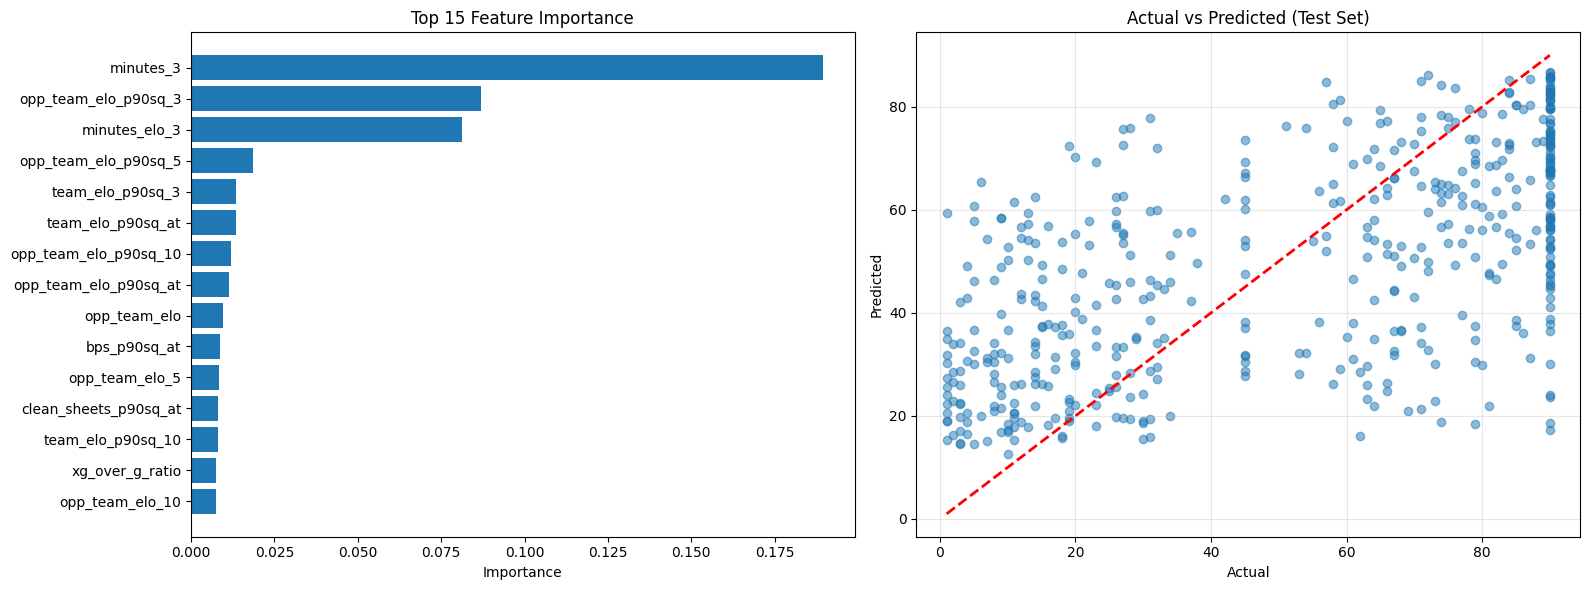

Cleaned df size: 8403/27969

Training Set Performance:
R² Score: 0.6616
RMSE: 18.7048
MAE: 15.3853

Test Set Performance:
R² Score: 0.3247
RMSE: 26.3905
MAE: 21.7604

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.369983
   opp_team_elo_p90sq_10    0.023104
    opp_team_elo_p90sq_3    0.016978
                  bps_10    0.013062
    opp_team_elo_p90sq_5    0.012239
              minutes_10    0.011732
           minutes_elo_3    0.011271
        team_elo_p90sq_3    0.010435
          minutes_elo_10    0.010414
         xg_over_g_ratio    0.009630
       minutes_elo_p90_5    0.008536
            opp_team_elo    0.008423
   clean_sheets_p90sq_at    0.007378
       team_elo_p90sq_10    0.007010
         opp_team_elo_10    0.006791
          opp_team_elo_5    0.006680
          opp_team_elo_3    0.006356
        team_elo_p90sq_5    0.006082
 goals_conceded_p90sq_at    0.005817
xgoals_conceded_p90sq_at    0.005762


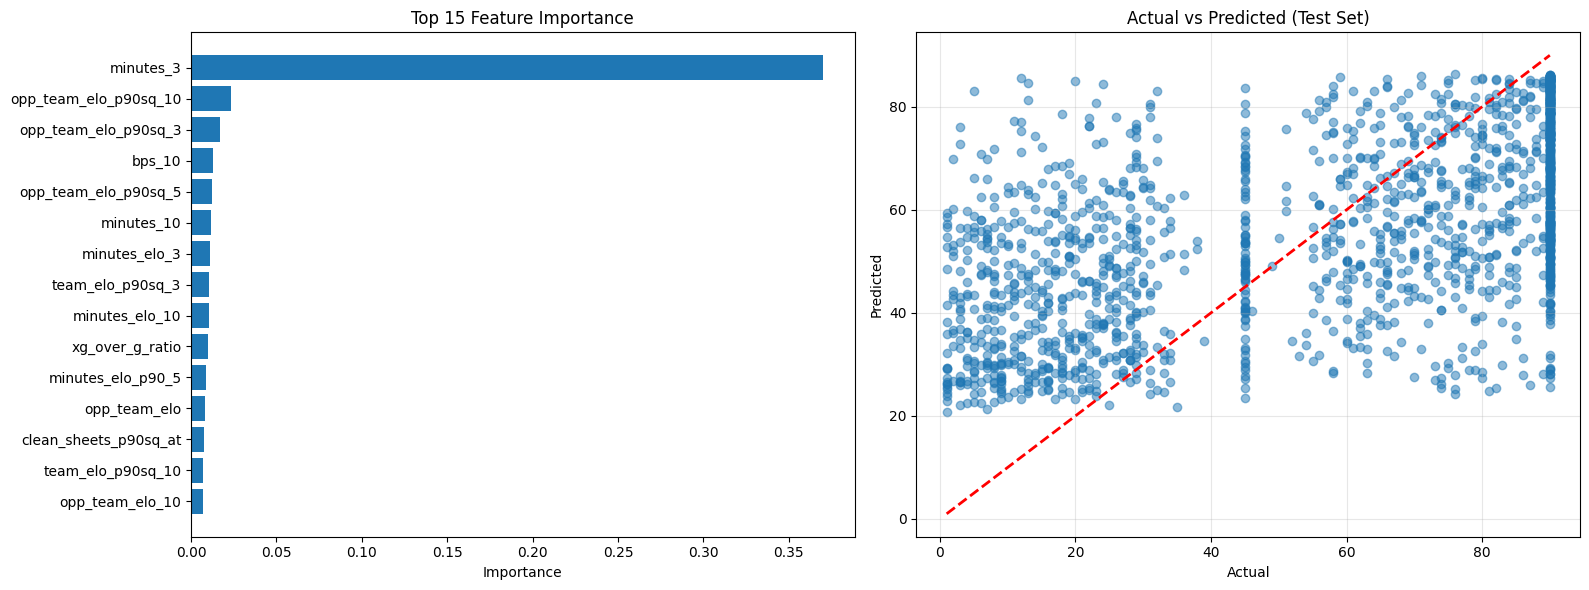

Cleaned df size: 5240/20145

Training Set Performance:
R² Score: 0.6835
RMSE: 16.7151
MAE: 12.5990

Test Set Performance:
R² Score: 0.1771
RMSE: 25.1720
MAE: 18.7971

Top 20 Feature Importances:
                feature  importance
              minutes_3    0.171319
   opp_team_elo_p90sq_3    0.052426
       team_elo_p90sq_3    0.027850
  opp_team_elo_p90sq_10    0.015202
      team_elo_p90sq_10    0.014617
        xg_over_g_ratio    0.012698
       team_elo_p90sq_5    0.011629
      xassists_p90sq_at    0.011222
         opp_team_elo_3    0.010781
   opp_team_elo_p90sq_5    0.010107
           opp_team_elo    0.009122
        opp_team_elo_10    0.009097
               elo_diff    0.009088
          minutes_elo_3    0.008922
goals_conceded_p90sq_at    0.008635
         opp_team_elo_5    0.008534
     total_points_p90_5    0.008283
  clean_sheets_p90sq_at    0.008277
  total_points_p90sq_at    0.008035
         bonus_p90sq_at    0.008011


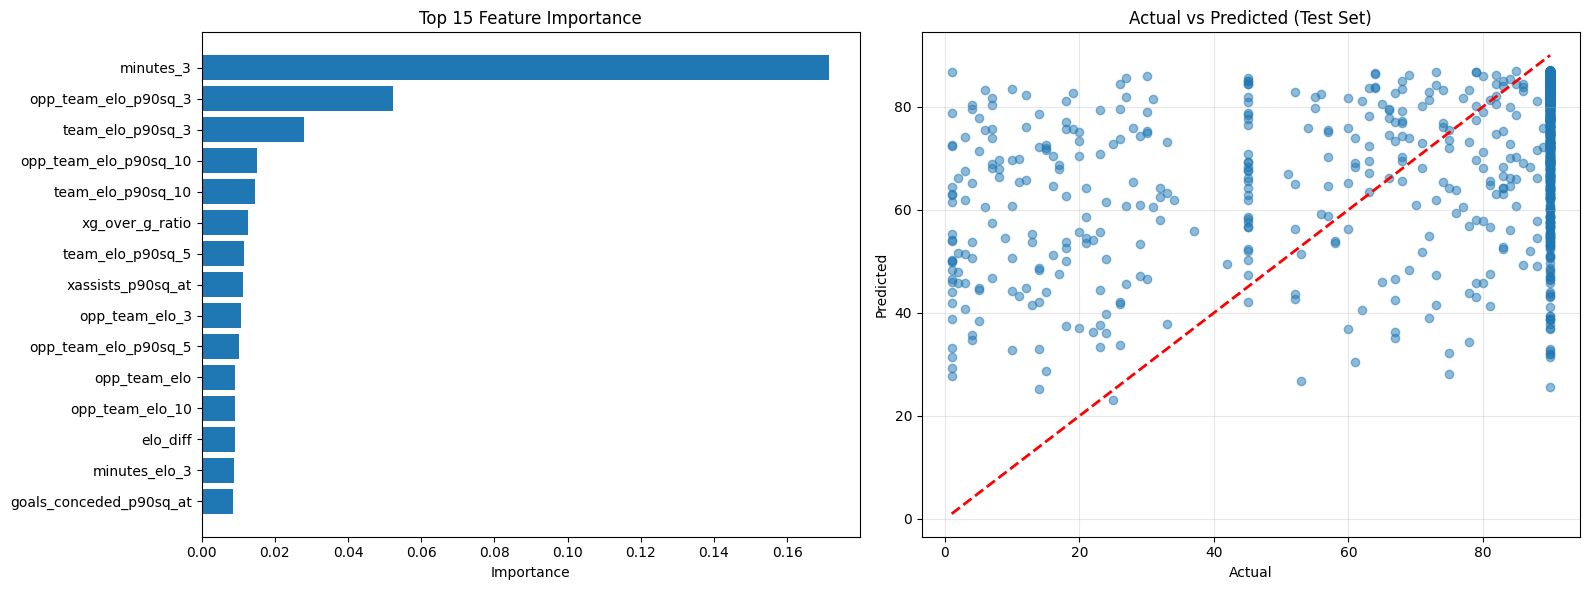

Cleaned df size: 3899/4162

Training Set Performance:
R² Score: 0.7088
RMSE: 2.6737
MAE: 0.5254

Test Set Performance:
R² Score: -0.0798
RMSE: 6.0344
MAE: 1.2519

Top 20 Feature Importances:
              feature  importance
opp_team_elo_p90sq_at    0.066848
         opp_team_elo    0.059762
         bps_p90sq_at    0.030227
          bps_p90sq_3    0.028215
             elo_diff    0.026976
    saves_elo_p90sq_3    0.023943
               bps_10    0.023642
          bps_p90sq_5    0.020705
                bps_5    0.019930
    team_elo_p90sq_at    0.019560
      opp_team_elo_10    0.019096
            bps_p90_5    0.018469
opp_team_elo_p90sq_10    0.016069
         bps_p90sq_10    0.014581
total_points_p90sq_at    0.014365
   opp_team_elo_elo_3    0.012233
   total_points_p90_5    0.012197
       saves_p90sq_at    0.012048
total_points_p90sq_10    0.011781
       opp_team_elo_3    0.011437


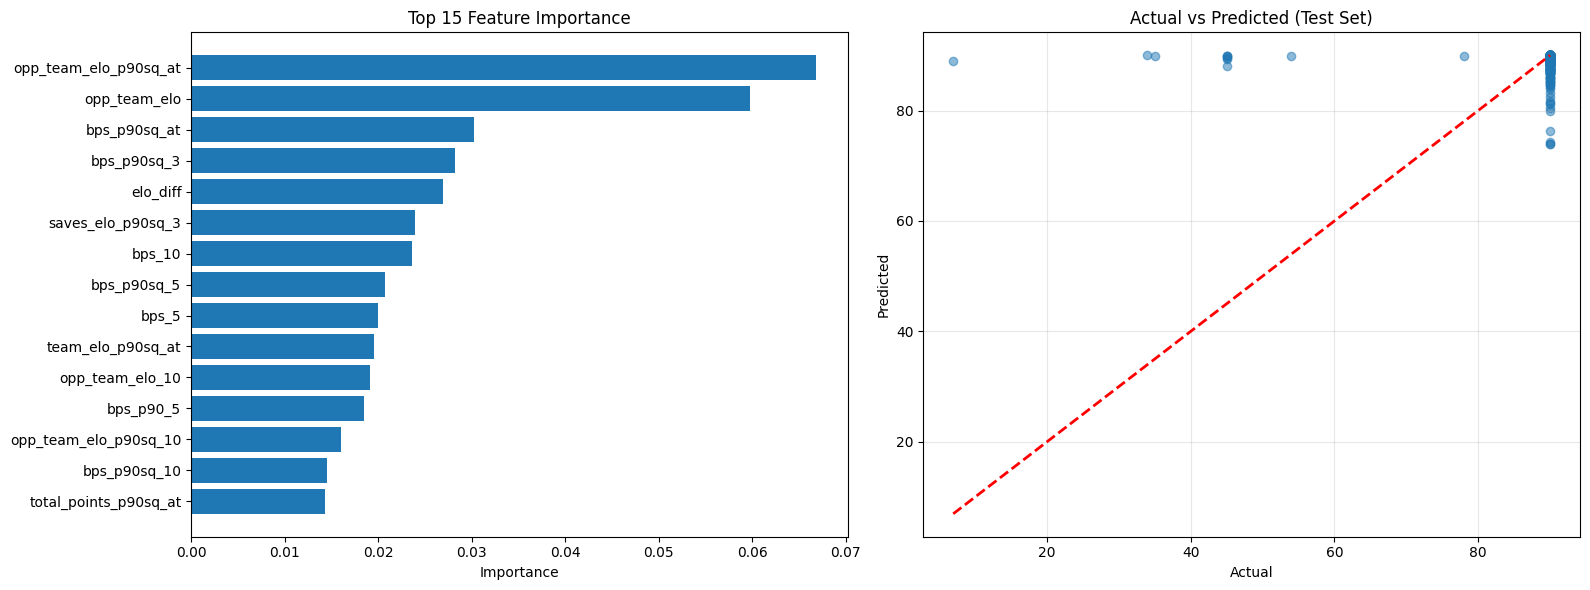

In [12]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2588/4300

Training Set Performance:
R² Score: 0.5878
RMSE: 0.2490
MAE: 0.1992

Test Set Performance:
R² Score: 0.0034
RMSE: 0.3968
MAE: 0.2998

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.050164
  goals_scored_p90sq_at    0.024899
        xg_over_g_ratio    0.022787
               team_elo    0.021681
    goals_scored_elo_10    0.020043
        opp_team_elo_10    0.018946
           opp_team_elo    0.018606
         opp_team_elo_5    0.018395
       team_elo_p90sq_3    0.015783
    total_points_p90_10    0.015505
   opp_team_elo_p90sq_3    0.015224
         opp_team_elo_3    0.014995
      team_elo_p90sq_at    0.012344
  opp_team_elo_p90sq_at    0.011913
goals_conceded_p90sq_at    0.011674
  clean_sheets_p90sq_at    0.010358
      minutes_elo_p90_3    0.010268
     total_points_elo_5    0.009567
    team_elo_elo_p90_10    0.009327
         bonus_p90sq_at    0.009257


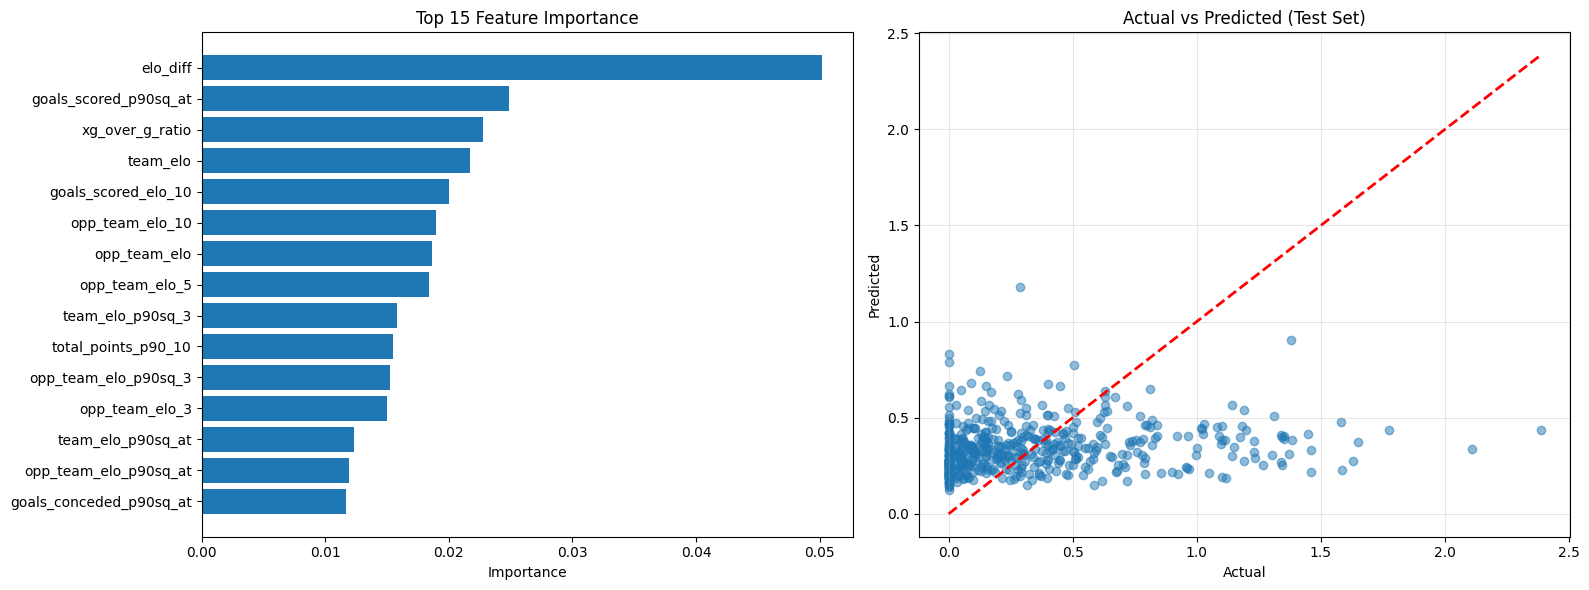

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 11970/18387

Training Set Performance:
R² Score: 0.4043
RMSE: 0.1730
MAE: 0.1176

Test Set Performance:
R² Score: 0.0766
RMSE: 0.2029
MAE: 0.1336

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.145919
           opp_team_elo    0.037446
         bonus_p90sq_at    0.027777
               elo_diff    0.020208
        opp_team_elo_10    0.018920
  clean_sheets_p90sq_at    0.017682
           bps_p90sq_10    0.014480
    total_points_elo_10    0.013943
           bps_p90sq_at    0.013809
  total_points_p90sq_at    0.011878
         opp_team_elo_3    0.011354
       bps_elo_p90sq_10    0.010937
  opp_team_elo_p90sq_at    0.010673
      team_elo_p90sq_at    0.010618
goals_conceded_p90sq_at    0.010483
     total_points_elo_5    0.010215
             bps_elo_10    0.009832
         opp_team_elo_5    0.009778
  opp_team_elo_p90sq_10    0.009630
    goals_scored_elo_10    0.009144


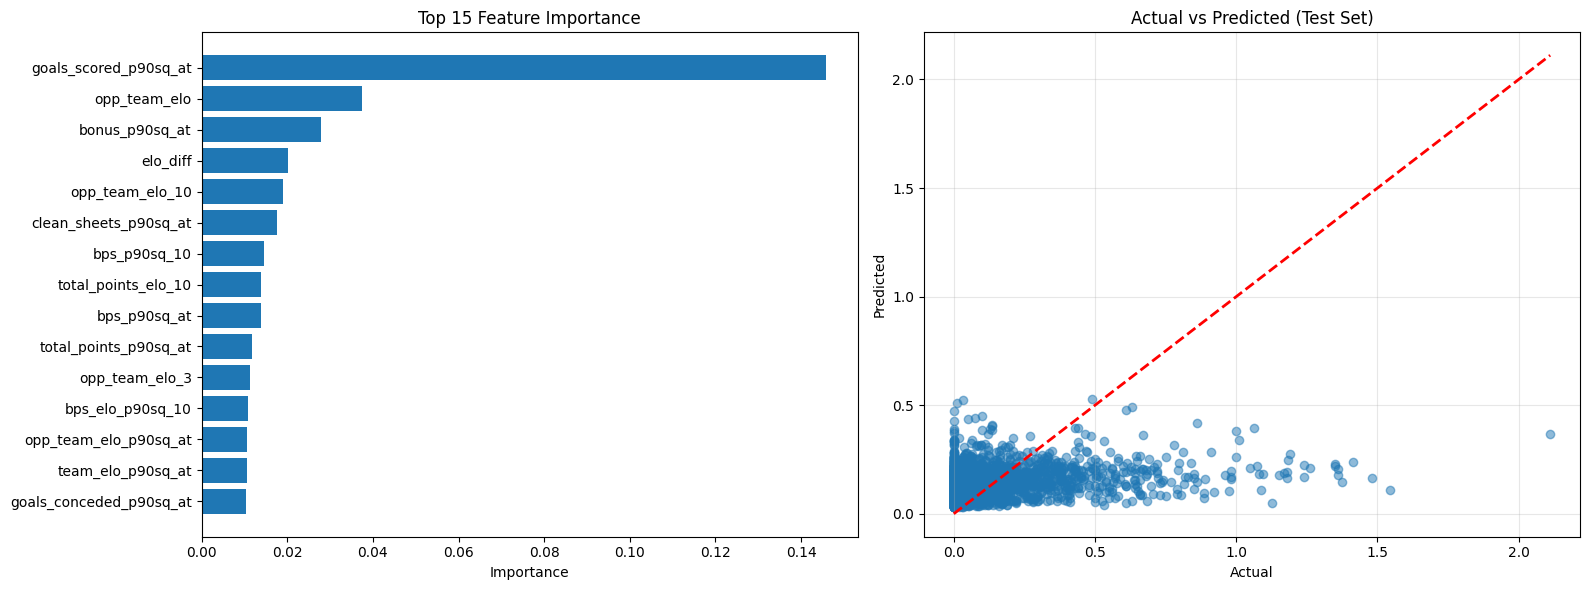

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10249/16446

Training Set Performance:
R² Score: 0.2755
RMSE: 0.0921
MAE: 0.0560

Test Set Performance:
R² Score: -0.0329
RMSE: 0.1006
MAE: 0.0584

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.041892
           opp_team_elo_3    0.041156
             opp_team_elo    0.031893
             bps_p90sq_at    0.022181
      goals_scored_elo_10    0.022135
        team_elo_p90sq_at    0.020815
     opp_team_elo_p90sq_3    0.018510
  goals_conceded_p90sq_at    0.018022
                 elo_diff    0.017973
    opp_team_elo_p90sq_10    0.017025
       total_points_elo_5    0.015928
    total_points_p90sq_at    0.015218
    goals_conceded_elo_10    0.014620
   opp_team_elo_elo_p90_3    0.013009
           opp_team_elo_5    0.012440
goals_conceded_elo_p90_10    0.011352
 goals_conceded_elo_p90_5    0.011283
               bps_elo_10    0.011225
              team_elo_10    0.010713
 

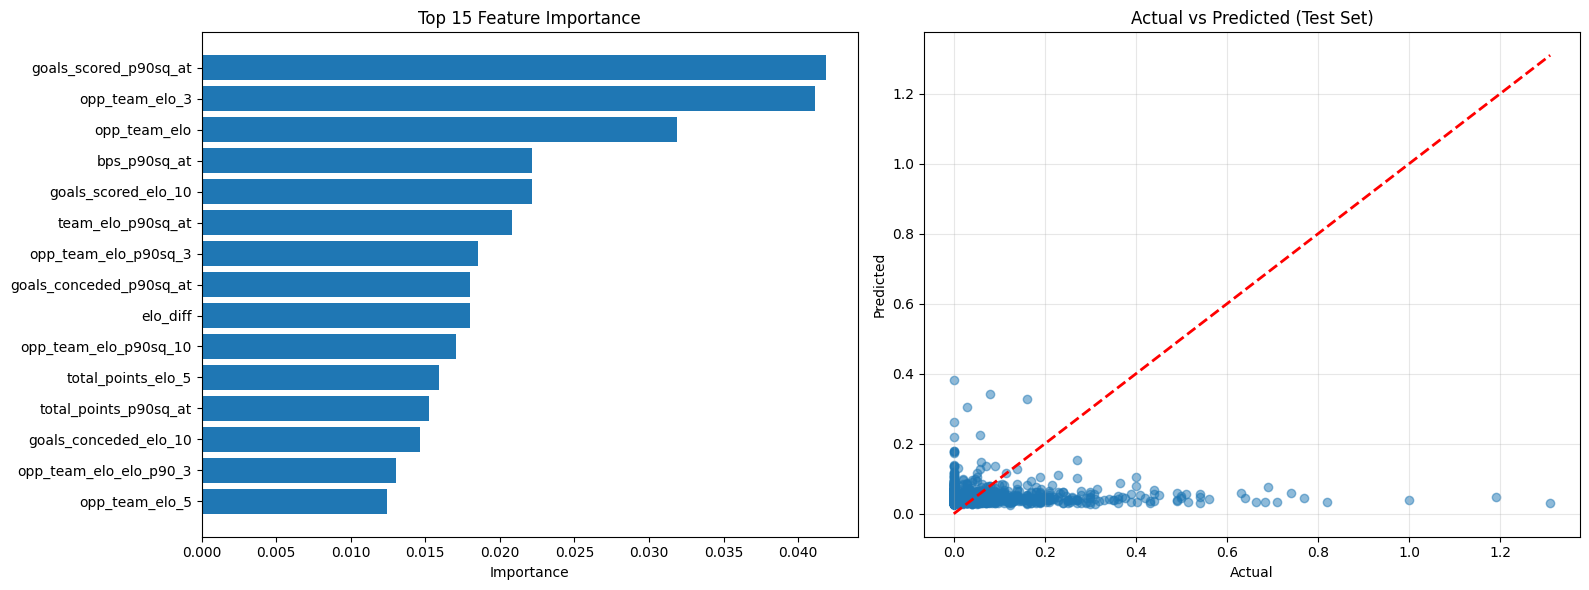

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2781/4583

Training Set Performance:
R² Score: 0.5141
RMSE: 0.0829
MAE: 0.0555

Test Set Performance:
R² Score: 0.0027
RMSE: 0.1282
MAE: 0.0800

Top 20 Feature Importances:
                 feature  importance
            opp_team_elo    0.036682
                elo_diff    0.027763
    total_points_p90sq_3    0.022751
       minutes_elo_p90_5    0.021435
          opp_team_elo_3    0.021372
             bonus_elo_5    0.019925
       minutes_elo_p90_3    0.018788
      goals_scored_p90_5    0.018123
  opp_team_elo_elo_p90_5    0.017037
              bps_elo_10    0.013473
total_points_elo_p90sq_3    0.012677
 opp_team_elo_elo_p90_10    0.012608
            bonus_elo_10    0.011889
          opp_team_elo_5    0.011844
         xg_over_g_ratio    0.011612
             bps_p90sq_3    0.010975
         opp_team_elo_10    0.010282
    goals_conceded_elo_3    0.010060
   goals_scored_p90sq_10    0.010027
    opp_team_elo_p90sq

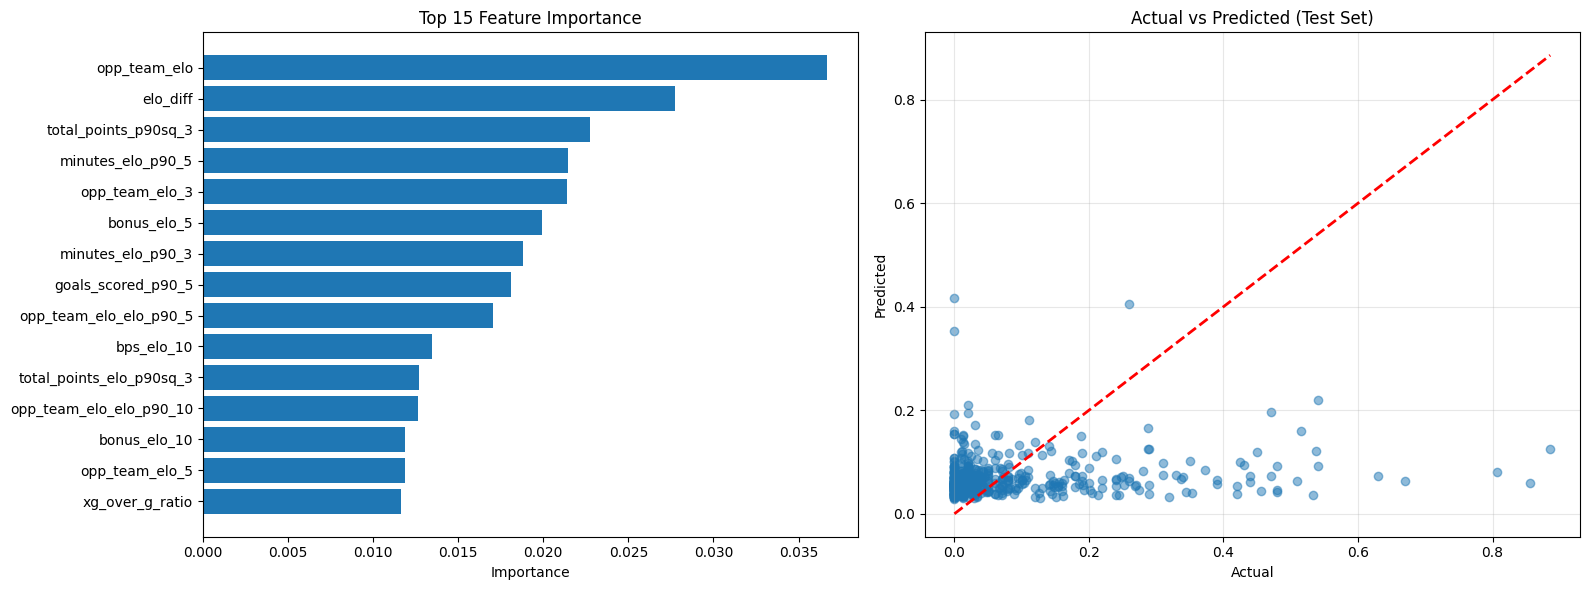

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12395/19016

Training Set Performance:
R² Score: 0.4139
RMSE: 0.1249
MAE: 0.0886

Test Set Performance:
R² Score: 0.0602
RMSE: 0.1566
MAE: 0.1071

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.096921
         bonus_p90sq_at    0.076432
             bps_elo_10    0.030420
           opp_team_elo    0.024165
  goals_scored_p90sq_at    0.021127
        opp_team_elo_10    0.016379
    total_points_elo_10    0.014972
         opp_team_elo_5    0.014805
           bps_p90sq_at    0.014515
      team_elo_p90sq_at    0.013847
         opp_team_elo_3    0.012639
                 bps_10    0.012314
  clean_sheets_p90sq_at    0.012102
            team_elo_10    0.009998
                  bps_3    0.009870
          bps_elo_p90_5    0.009853
goals_conceded_p90sq_at    0.009352
  opp_team_elo_p90sq_at    0.009084
  total_points_p90sq_at    0.008888
    total_points_p90_10    0.008871


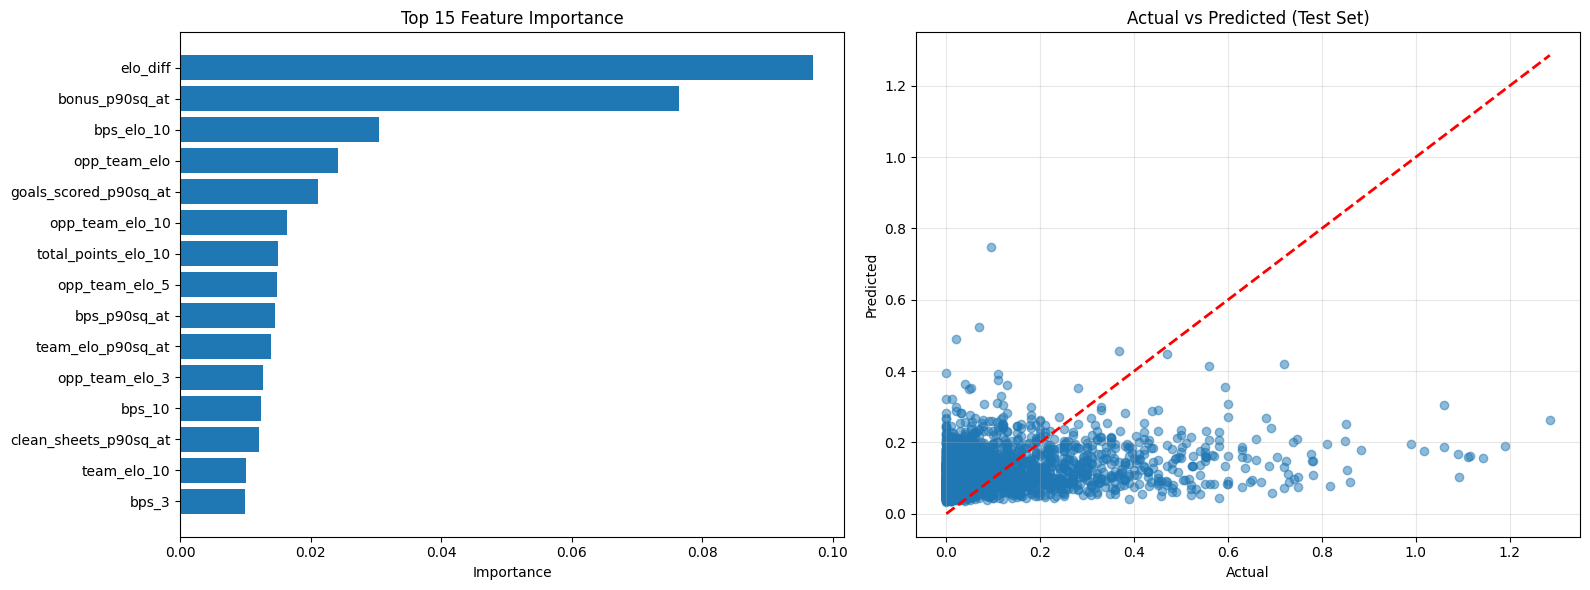

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10446/16767

Training Set Performance:
R² Score: 0.3809
RMSE: 0.0823
MAE: 0.0511

Test Set Performance:
R² Score: 0.0251
RMSE: 0.1030
MAE: 0.0572

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.105809
               elo_diff    0.045054
           opp_team_elo    0.031586
    minutes_elo_p90sq_3    0.022420
goals_conceded_p90sq_at    0.022351
          bps_elo_p90_5    0.019291
        opp_team_elo_10    0.017372
                  bps_3    0.016699
  goals_scored_p90sq_at    0.016232
  clean_sheets_p90sq_at    0.014702
               team_elo    0.014239
   goals_conceded_elo_3    0.014174
         opp_team_elo_3    0.014041
         minutes_elo_10    0.013731
         opp_team_elo_5    0.013055
           bps_p90sq_at    0.012716
      team_elo_p90sq_at    0.011879
              bps_p90_5    0.011488
            bps_p90sq_5    0.011343
 opp_team_elo_elo_p90_3    0.011027


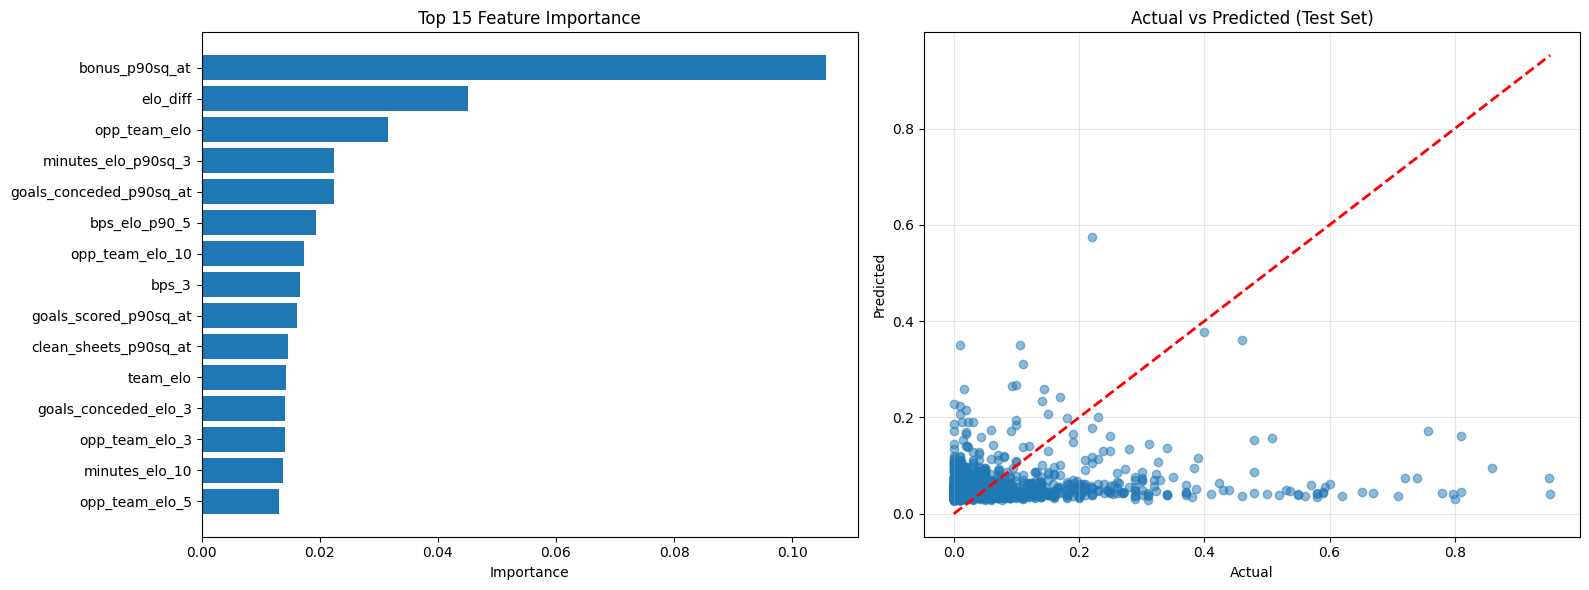

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2781/4583


c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Chris\OneDrive\Documents\Coding\FPL-Points-Predictor\fplenv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j


Training Set Performance:
R² Score: 0.6802
RMSE: 0.5274
MAE: 0.4248

Test Set Performance:
R² Score: 0.1138
RMSE: 0.8703
MAE: 0.6811

Top 20 Feature Importances:
                   feature  importance
                  elo_diff    0.161937
              opp_team_elo    0.047887
           xg_over_g_ratio    0.038931
     clean_sheets_p90sq_at    0.025917
           opp_team_elo_10    0.016387
   goals_conceded_p90sq_at    0.015725
            opp_team_elo_5    0.014421
        minutes_elo_p90_10    0.013729
            opp_team_elo_3    0.013515
                minutes_10    0.009687
            bonus_p90sq_at    0.009069
         minutes_elo_p90_3    0.008758
     goals_conceded_elo_10    0.008670
goals_conceded_elo_p90sq_5    0.008403
      goals_conceded_elo_3    0.008277
     goals_scored_p90sq_at    0.007956
        opp_team_elo_elo_5    0.007716
  total_points_elo_p90sq_3    0.007699
     opp_team_elo_p90sq_at    0.007698
      opp_team_elo_p90sq_3    0.007534


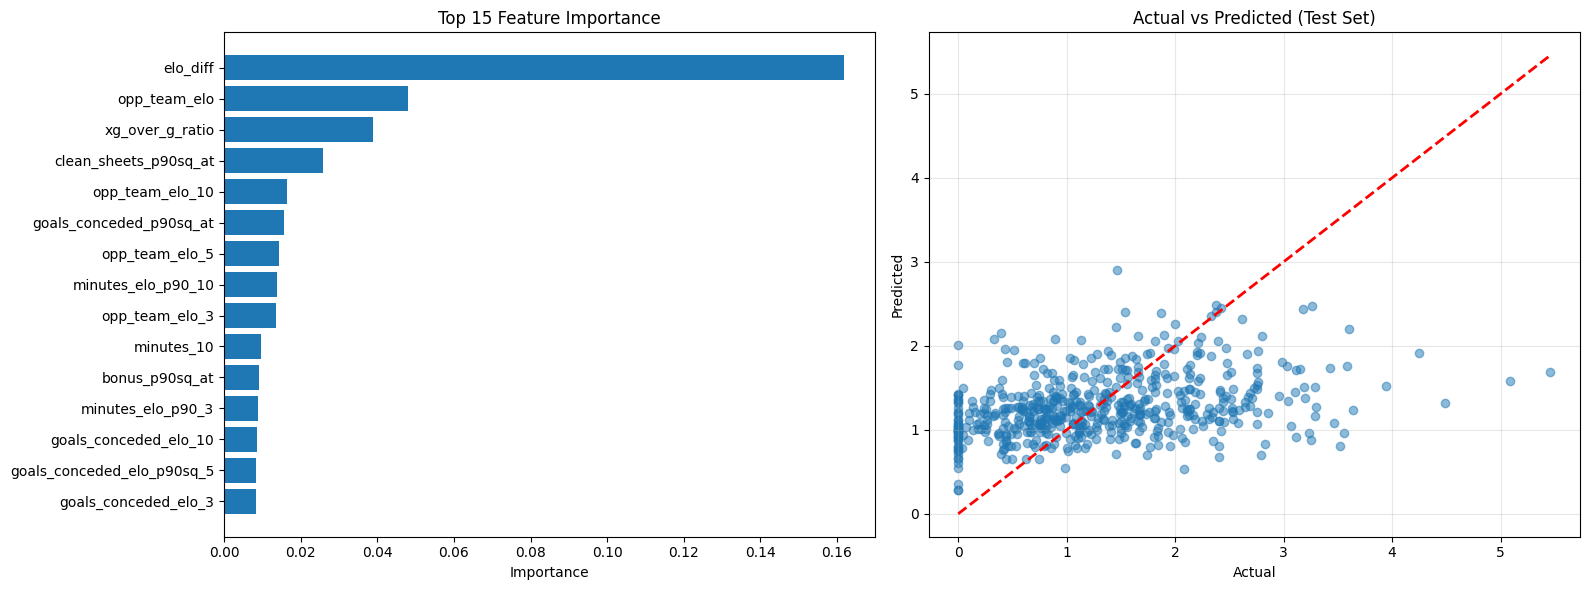

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12395/19016

Training Set Performance:
R² Score: 0.5502
RMSE: 0.6248
MAE: 0.4973

Test Set Performance:
R² Score: 0.3206
RMSE: 0.7890
MAE: 0.6105

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.247041
         opp_team_elo    0.078269
       opp_team_elo_5    0.041318
      opp_team_elo_10    0.035238
       opp_team_elo_3    0.027886
             team_elo    0.025097
          team_elo_10    0.023791
       team_elo_elo_3    0.022428
           team_elo_5    0.021096
           team_elo_3    0.020127
   opp_team_elo_elo_3    0.019329
   opp_team_elo_elo_5    0.016217
       team_elo_elo_5    0.015422
    minutes_elo_p90_3    0.013606
clean_sheets_p90sq_at    0.012907
  minutes_elo_p90sq_3    0.011815
      team_elo_elo_10    0.010525
  opp_team_elo_elo_10    0.009826
 goals_conceded_elo_5    0.009188
 minutes_elo_p90sq_10    0.008941


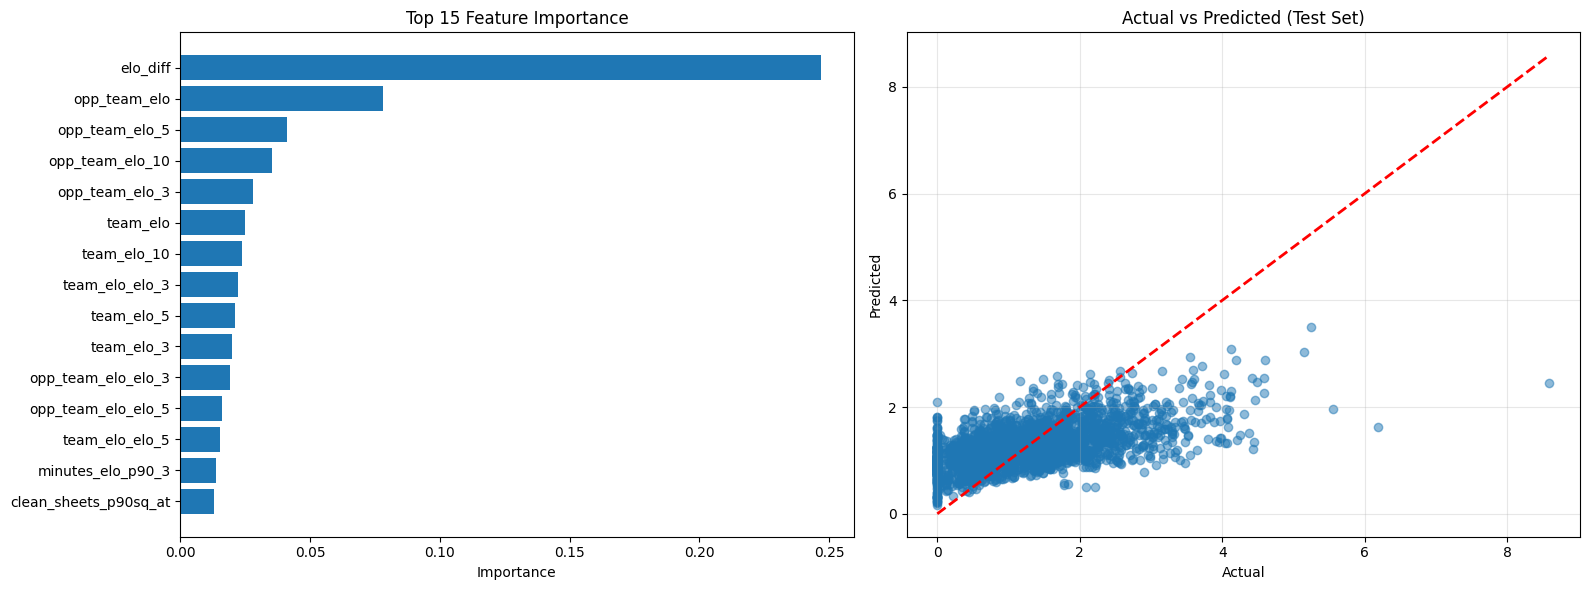

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10446/16767

Training Set Performance:
R² Score: 0.5820
RMSE: 0.6092
MAE: 0.4842

Test Set Performance:
R² Score: 0.3258
RMSE: 0.7505
MAE: 0.5959

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.180790
           opp_team_elo    0.100872
        opp_team_elo_10    0.030505
         opp_team_elo_5    0.030469
    opp_team_elo_elo_10    0.029428
               team_elo    0.025181
            team_elo_10    0.024170
             team_elo_5    0.022860
         team_elo_elo_3    0.020106
         opp_team_elo_3    0.019611
     opp_team_elo_elo_3    0.017840
             team_elo_3    0.017378
     opp_team_elo_elo_5    0.016338
goals_conceded_p90sq_at    0.015810
         team_elo_elo_5    0.015083
  clean_sheets_p90sq_at    0.014635
        team_elo_elo_10    0.011749
      minutes_elo_p90_3    0.010679
    minutes_elo_p90sq_3    0.010420
  opp_team_elo_p90sq_at    0.009

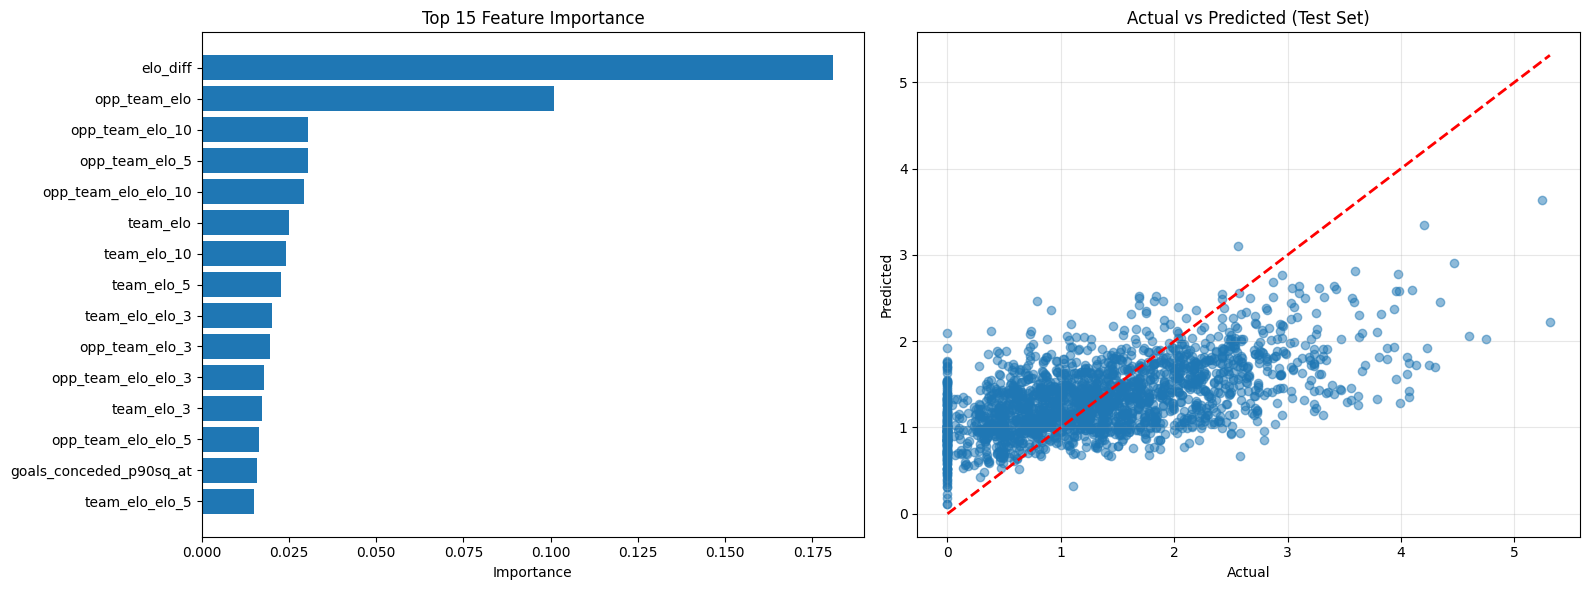

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2564/4100

Training Set Performance:
R² Score: 0.7026
RMSE: 0.5094
MAE: 0.4128

Test Set Performance:
R² Score: 0.1262
RMSE: 0.8080
MAE: 0.6139

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.167204
           opp_team_elo    0.042766
  opp_team_elo_p90sq_10    0.028013
         saves_p90sq_at    0.027999
  opp_team_elo_p90sq_at    0.023135
goals_conceded_p90sq_at    0.021726
      team_elo_p90sq_at    0.018654
        opp_team_elo_10    0.016330
      saves_elo_p90sq_3    0.013991
           bps_p90sq_at    0.013932
         opp_team_elo_5    0.013309
  clean_sheets_p90sq_at    0.013131
     saves_elo_p90sq_10    0.012923
         saves_p90sq_10    0.012755
  total_points_p90sq_at    0.012074
   opp_team_elo_p90sq_3    0.010853
      saves_elo_p90sq_5    0.010438
          saves_p90sq_3    0.010380
          saves_p90sq_5    0.010289
         opp_team_elo_3    0.010206

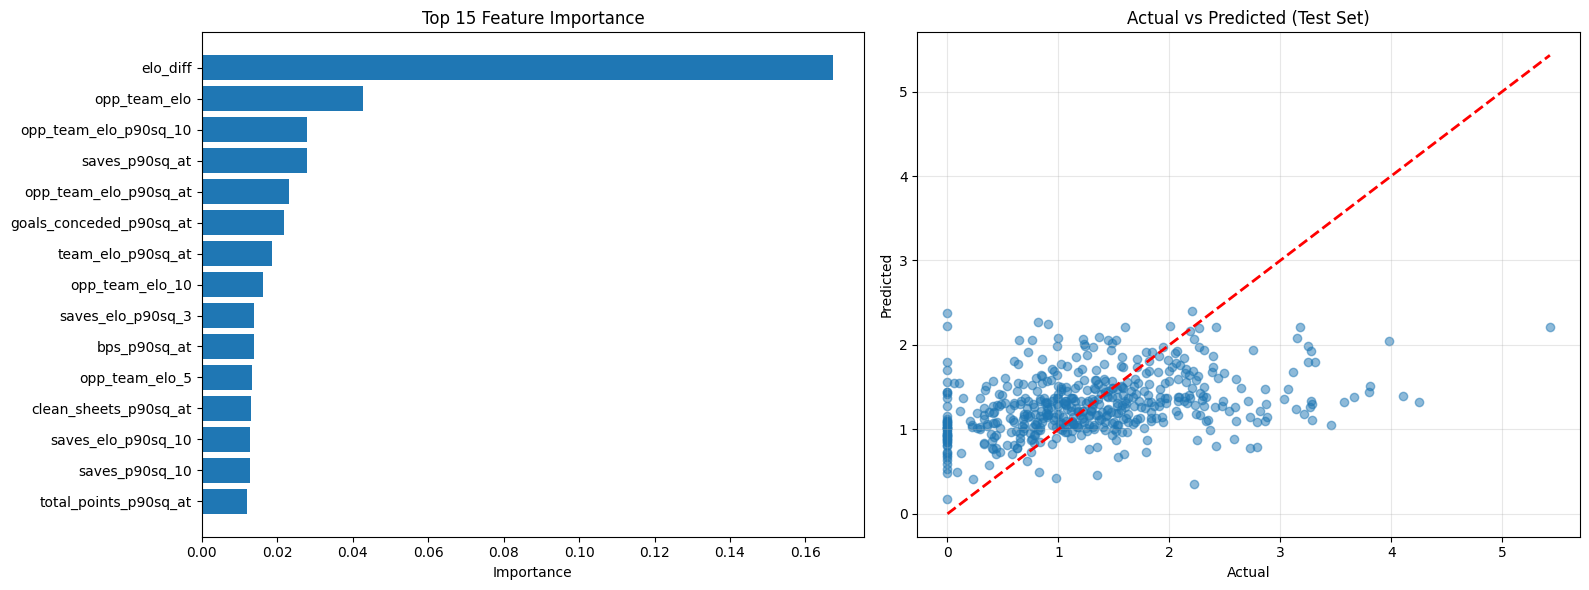

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4093/4583

Training Set Performance:
R² Score: 0.4848
RMSE: 13.4856
MAE: 10.9329

Test Set Performance:
R² Score: -0.0498
RMSE: 17.6946
MAE: 13.7420

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.076430
             opp_team_elo    0.028630
       opp_team_elo_elo_5    0.024385
          opp_team_elo_10    0.020490
           bonus_p90sq_at    0.017663
  goals_conceded_p90sq_at    0.016165
        minutes_elo_p90_5    0.015635
      minutes_elo_p90sq_3    0.012757
           opp_team_elo_5    0.012704
clean_sheets_elo_p90sq_10    0.011166
             bps_p90sq_at    0.011036
           opp_team_elo_3    0.010740
           minutes_elo_10    0.010031
total_points_elo_p90sq_10    0.009896
      clean_sheets_elo_10    0.009626
    clean_sheets_p90sq_at    0.009623
                bps_p90_5    0.009567
      minutes_elo_p90sq_5    0.009409
    opp_team_elo_p90sq_at    0.008892
         

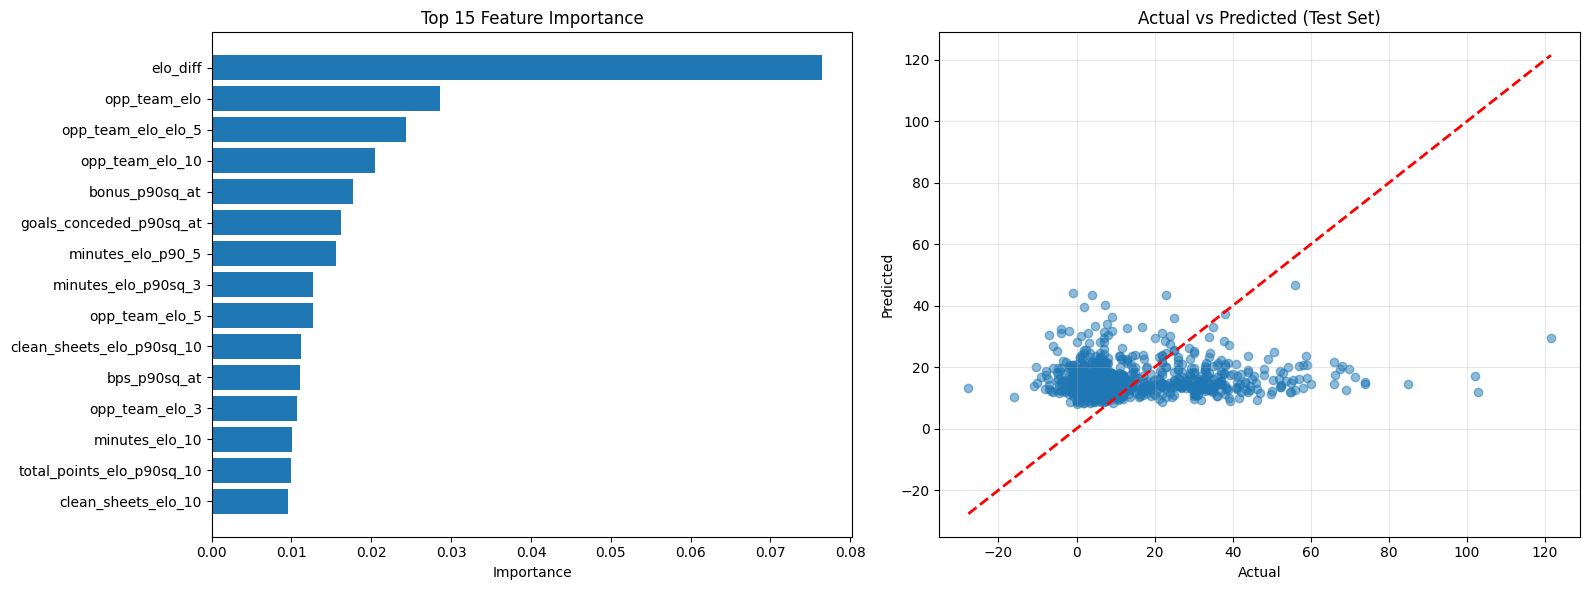

target=bps_per90, MID_bps_predictor
Cleaned df size: 18409/19016

Training Set Performance:
R² Score: 0.3235
RMSE: 9.4706
MAE: 7.1913

Test Set Performance:
R² Score: 0.0380
RMSE: 10.9964
MAE: 7.9598

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.134536
                 bps_10    0.029378
             bps_elo_10    0.025930
         bonus_p90sq_at    0.025049
           opp_team_elo    0.022500
                  bps_5    0.020078
        opp_team_elo_10    0.017349
         opp_team_elo_3    0.016584
         opp_team_elo_5    0.015498
  goals_scored_p90sq_at    0.013419
           bps_p90sq_at    0.010357
      team_elo_p90sq_at    0.010277
  clean_sheets_p90sq_at    0.009332
goals_conceded_p90sq_at    0.008822
goals_conceded_p90sq_10    0.008725
             bps_p90_10    0.008626
              bps_elo_3    0.008434
    total_points_elo_10    0.008359
  opp_team_elo_p90sq_at    0.007828
  total_points_p90sq_at    0.007754


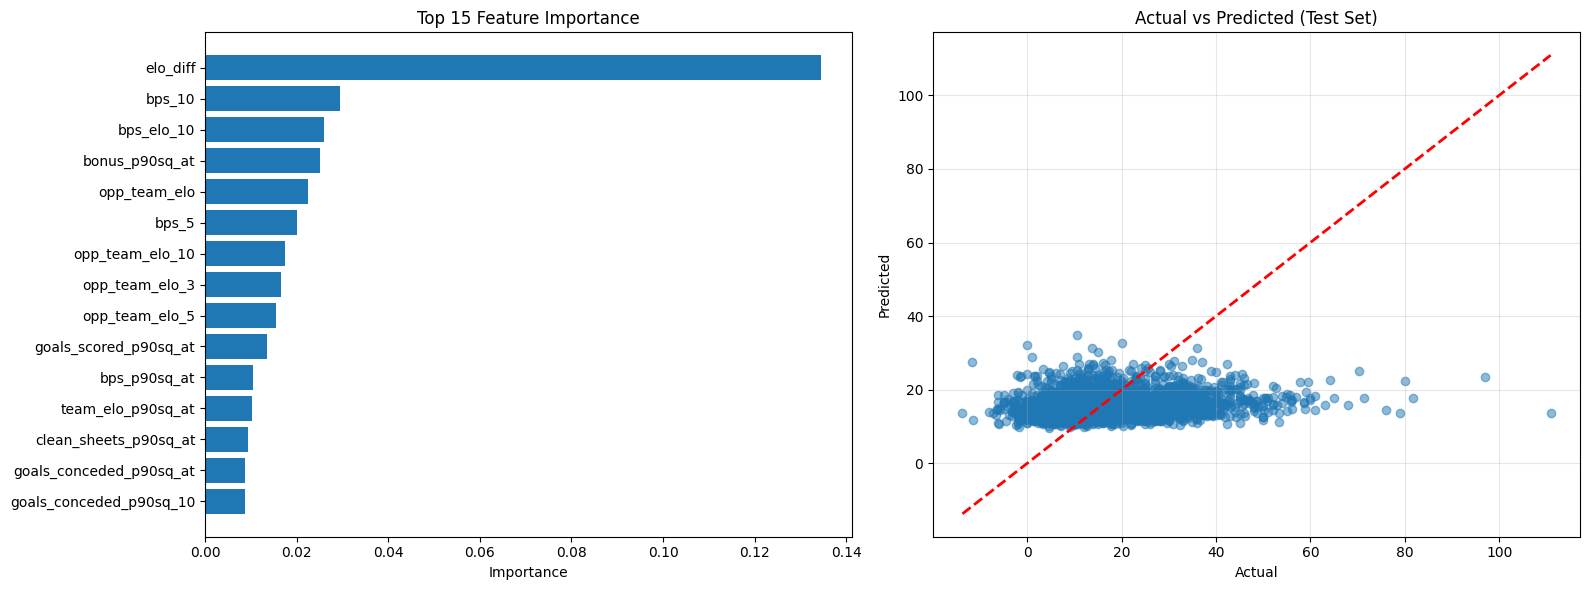

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15773/16767

Training Set Performance:
R² Score: 0.4148
RMSE: 7.5695
MAE: 6.0534

Test Set Performance:
R² Score: 0.1377
RMSE: 9.0878
MAE: 7.1561

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.233304
           opp_team_elo    0.030822
        opp_team_elo_10    0.024117
         opp_team_elo_5    0.022432
         opp_team_elo_3    0.016559
         bonus_p90sq_at    0.016341
             bps_p90_10    0.013239
                 bps_10    0.013229
goals_conceded_p90sq_at    0.012783
            bps_p90sq_5    0.012295
            team_elo_10    0.010931
               team_elo    0.010148
        bps_elo_p90sq_5    0.009646
       bps_elo_p90sq_10    0.009571
           bps_p90sq_10    0.009316
  clean_sheets_p90sq_at    0.009038
           bps_p90sq_at    0.008766
              bps_p90_5    0.008663
  goals_scored_p90sq_at    0.008350
        bps_elo_p90sq_3    0.008231


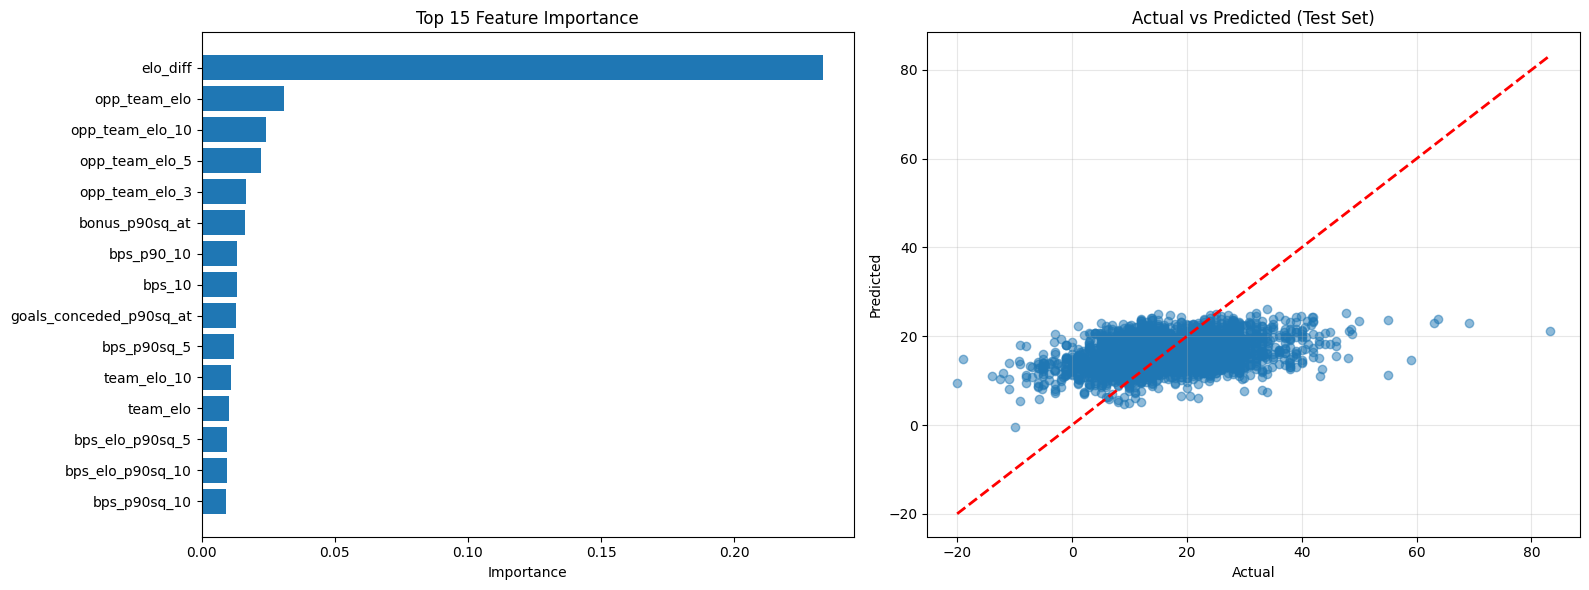

target=bps_per90, GK_bps_predictor
Cleaned df size: 3862/4100

Training Set Performance:
R² Score: 0.5330
RMSE: 6.1009
MAE: 4.9441

Test Set Performance:
R² Score: 0.0347
RMSE: 8.6361
MAE: 6.9708

Top 20 Feature Importances:
                    feature  importance
               bps_p90sq_10    0.037017
               opp_team_elo    0.033287
            opp_team_elo_10    0.033253
                 bps_p90_10    0.022346
      opp_team_elo_p90sq_at    0.021866
               bps_p90sq_at    0.018884
                bps_p90sq_5    0.018882
      total_points_p90sq_10    0.018843
                   elo_diff    0.016916
             saves_p90sq_10    0.016851
             opp_team_elo_5    0.016163
      opp_team_elo_p90sq_10    0.016074
    goals_conceded_p90sq_at    0.015540
             saves_p90sq_at    0.015510
          saves_elo_p90sq_3    0.014955
           bps_elo_p90sq_10    0.014683
      total_points_p90sq_at    0.014183
                bps_p90sq_3    0.013525
goals_conceded_

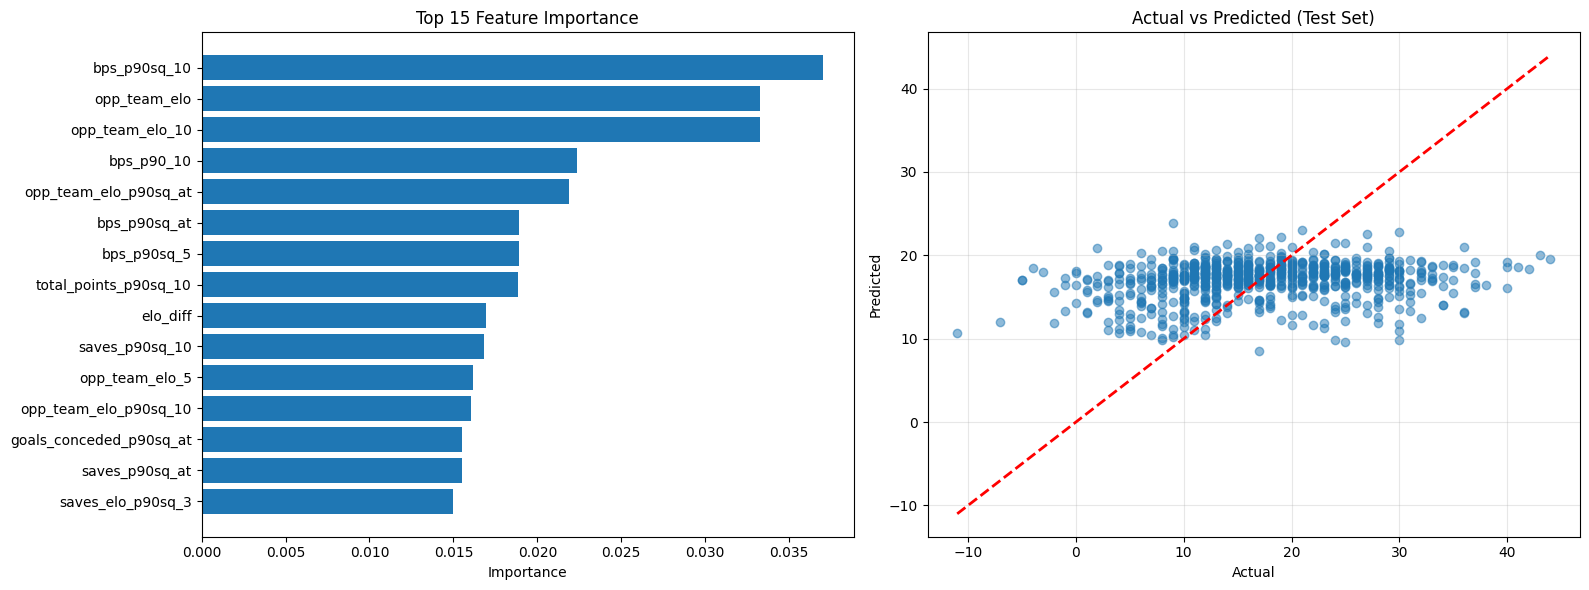

In [16]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3862/4119

Training Set Performance:
R² Score: 0.5877
RMSE: 1.2735
MAE: 1.0306

Test Set Performance:
R² Score: 0.0418
RMSE: 1.8297
MAE: 1.4694

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.133509
               opp_team_elo    0.021638
             saves_p90sq_at    0.020117
            opp_team_elo_10    0.019073
      opp_team_elo_p90sq_at    0.018834
             saves_p90sq_10    0.017290
    goals_conceded_p90sq_at    0.015316
          team_elo_p90sq_at    0.015142
             opp_team_elo_5    0.014741
             opp_team_elo_3    0.014200
   total_points_elo_p90sq_3    0.013530
              saves_p90sq_3    0.013135
              saves_p90sq_5    0.012643
            bps_elo_p90sq_5    0.012572
       opp_team_elo_p90sq_3    0.011462
             bonus_p90sq_at    0.011160
       opp_team_elo_p90sq_5    0.011017
               bps_p90sq_at    0.010686
goals_conce

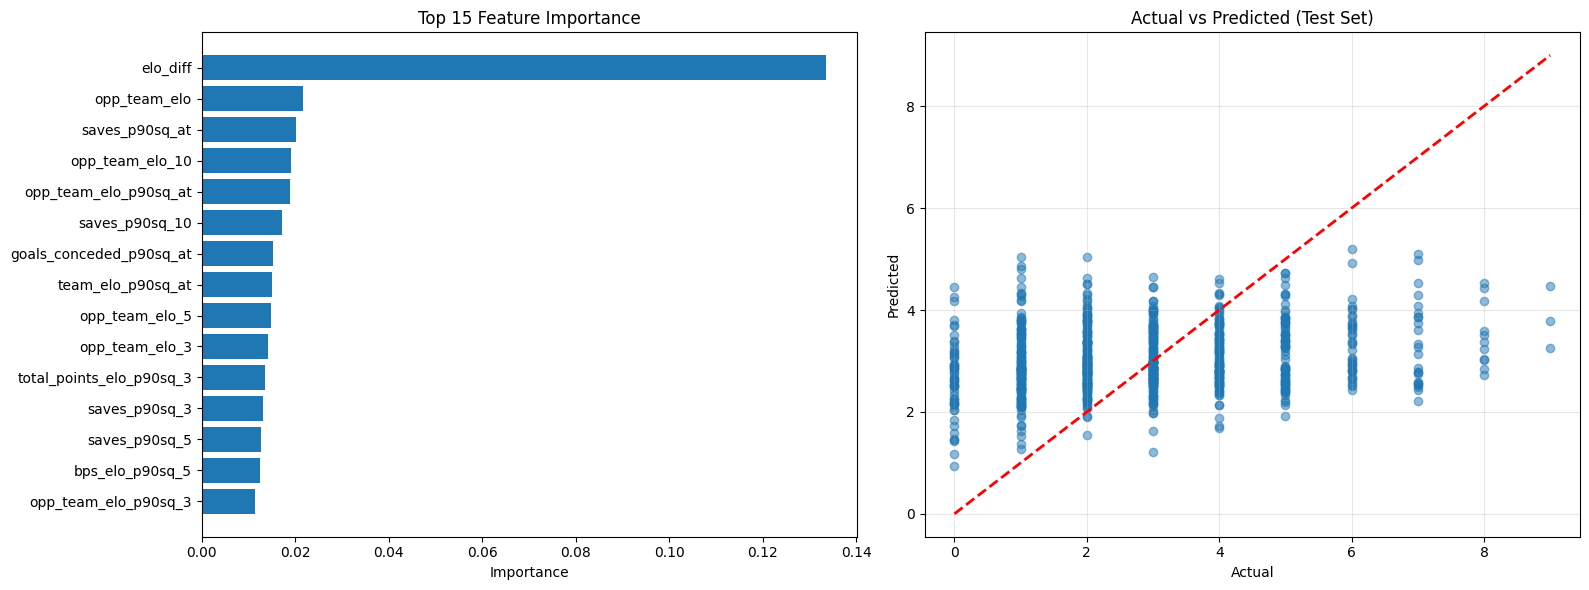

In [17]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 578/5064

Training Set Performance:
R² Score: 0.7840
RMSE: 1.2839
MAE: 1.0270

Test Set Performance:
R² Score: 0.1368
RMSE: 2.7589
MAE: 2.1511

Top 20 Feature Importances:
                   feature  importance
      total_points_p90sq_3    0.035779
            opp_team_elo_5    0.033701
                  team_elo    0.026807
     clean_sheets_p90sq_at    0.026133
     goals_scored_p90sq_at    0.019238
           opp_team_elo_10    0.019230
   goals_conceded_p90sq_at    0.018866
      opp_team_elo_p90sq_5    0.018269
         team_elo_p90sq_at    0.014948
     goals_conceded_p90_10    0.014670
            bonus_p90sq_at    0.014562
goals_conceded_elo_p90sq_5    0.013773
              opp_team_elo    0.013547
     opp_team_elo_p90sq_at    0.013458
     total_points_p90sq_at    0.013437
                  elo_diff    0.013115
            opp_team_elo_3    0.013081
       minutes_elo_p90sq_5    0.013039
          te

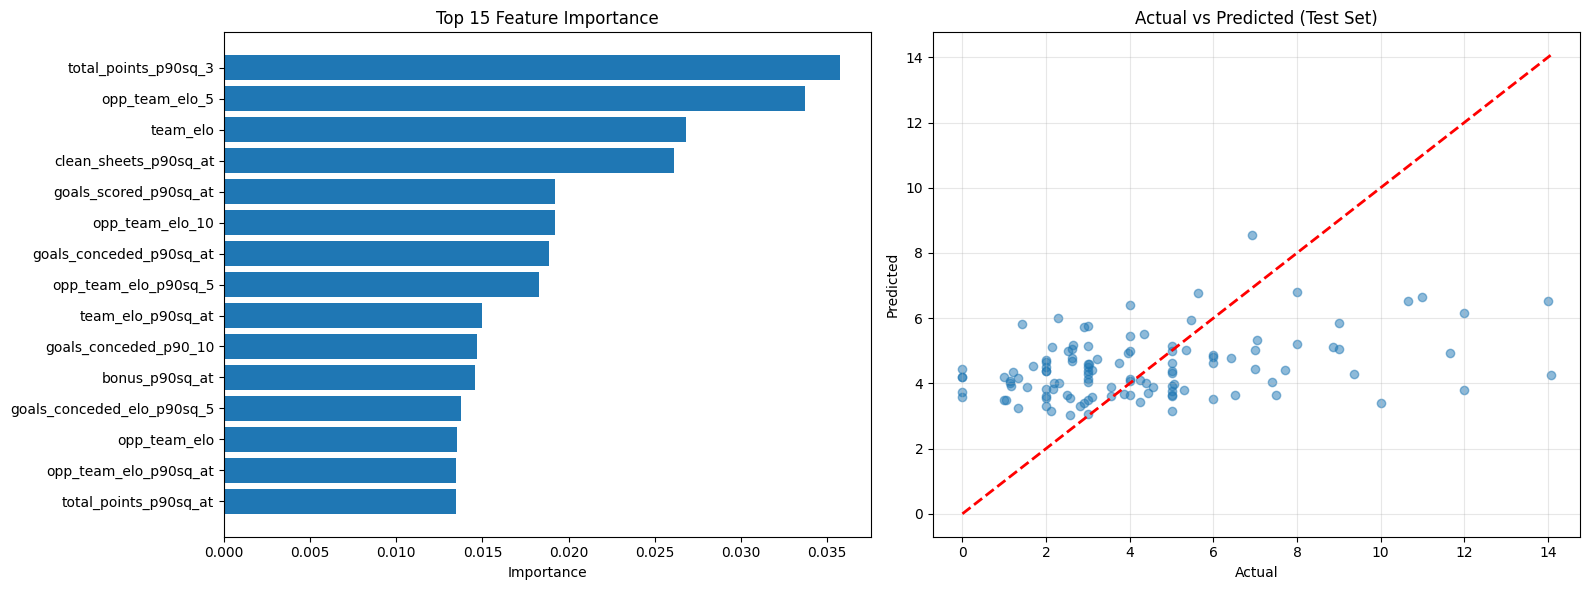

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2655/20912

Training Set Performance:
R² Score: 0.6739
RMSE: 2.4071
MAE: 1.9420

Test Set Performance:
R² Score: 0.1472
RMSE: 3.9571
MAE: 3.0970

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.094052
             bonus_p90sq_at    0.029336
    goals_conceded_p90sq_at    0.028472
      total_points_p90sq_at    0.022114
          team_elo_p90sq_at    0.017422
                   team_elo    0.015998
goals_conceded_elo_p90sq_10    0.015074
      goals_conceded_elo_10    0.012914
               bps_p90sq_at    0.012600
             opp_team_elo_5    0.012537
             opp_team_elo_3    0.012464
            opp_team_elo_10    0.012452
       opp_team_elo_p90sq_3    0.011939
                      bps_3    0.011924
      opp_team_elo_p90sq_at    0.011601
      clean_sheets_p90sq_at    0.011337
               opp_team_elo    0.011081
        team_elo_elo_p90_10    

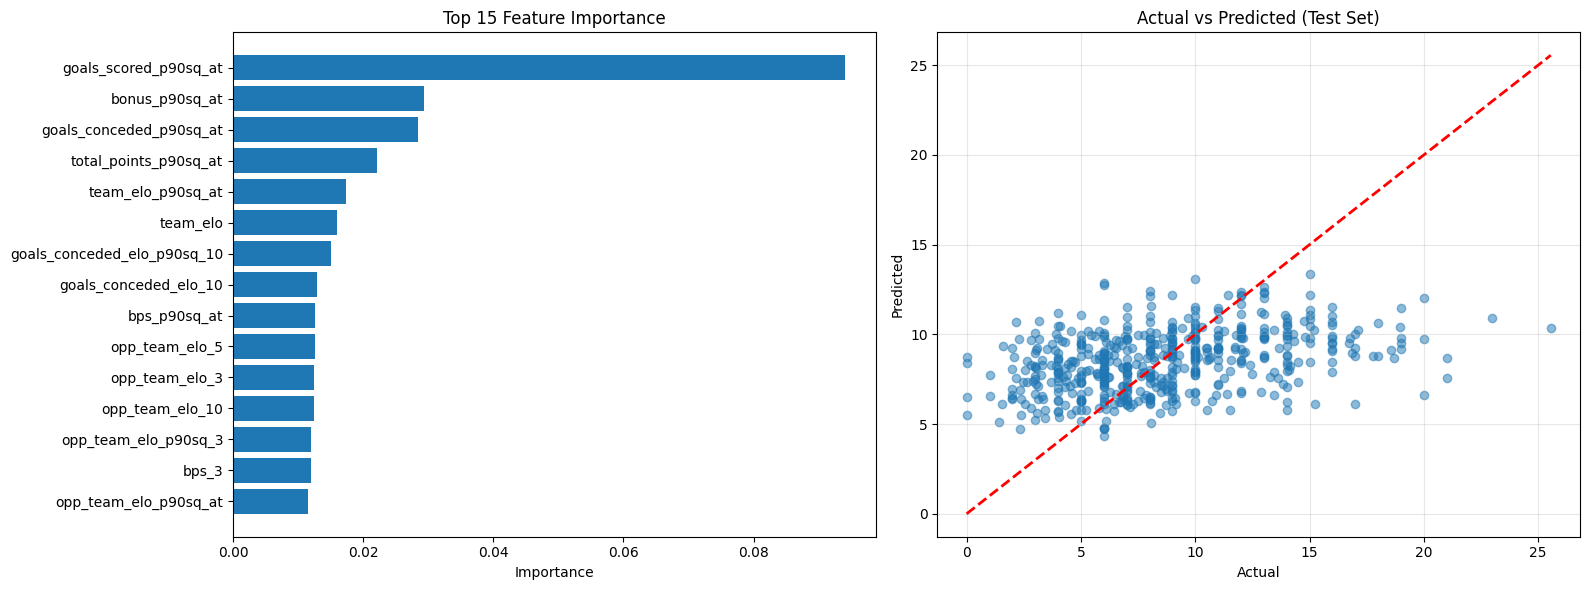

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2225/17722

Training Set Performance:
R² Score: 0.6624
RMSE: 2.2344
MAE: 1.8287

Test Set Performance:
R² Score: 0.0868
RMSE: 3.7246
MAE: 2.8594

Top 20 Feature Importances:
                feature  importance
  opp_team_elo_p90sq_at    0.029085
goals_conceded_p90sq_at    0.020802
      team_elo_p90sq_at    0.020501
         opp_team_elo_3    0.019045
         bonus_p90sq_at    0.018908
           opp_team_elo    0.016726
               elo_diff    0.016706
  total_points_p90sq_at    0.016431
  opp_team_elo_p90sq_10    0.015532
  total_points_p90sq_10    0.015312
       team_elo_p90sq_5    0.015105
   opp_team_elo_p90sq_5    0.014408
  goals_conceded_elo_10    0.014284
opp_team_elo_elo_p90_10    0.014135
 opp_team_elo_elo_p90_5    0.013898
        opp_team_elo_10    0.013825
           bps_p90sq_at    0.013648
        bps_elo_p90sq_5    0.013048
     minutes_elo_p90_10    0.012830
  goals_scored_p90sq_at    0.01

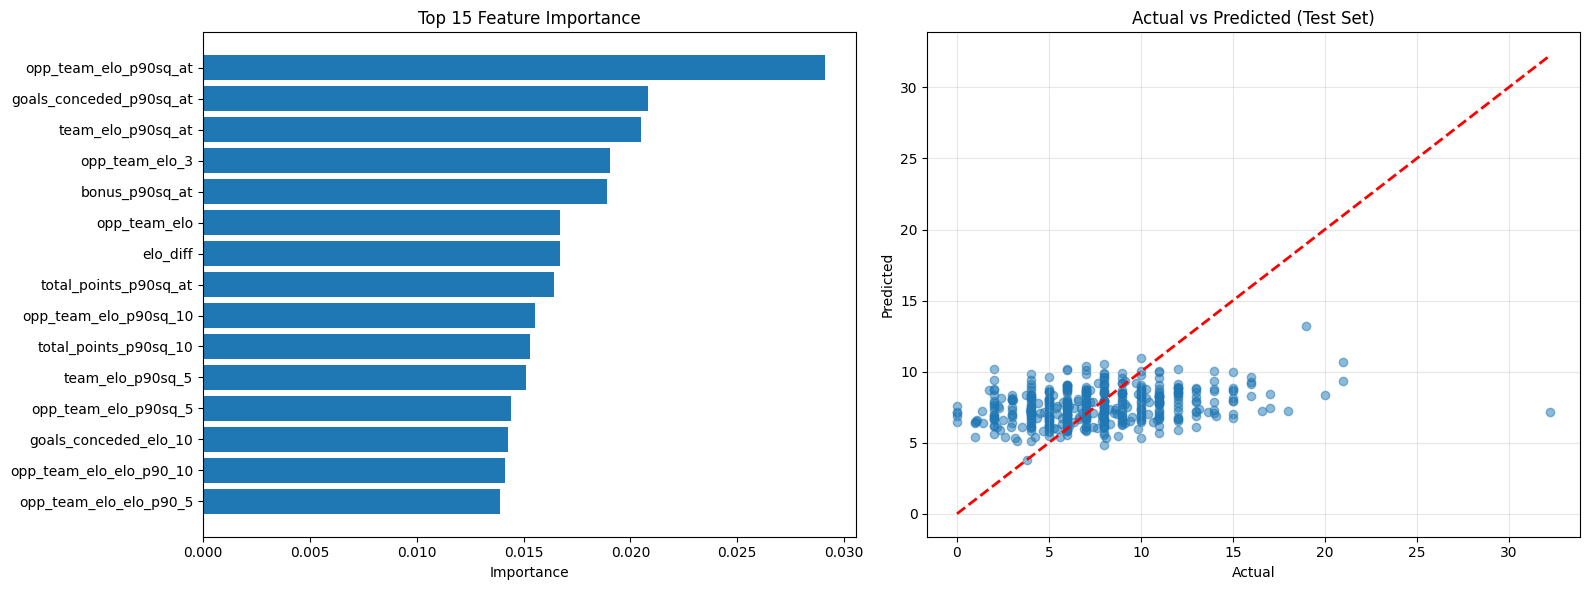

In [18]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

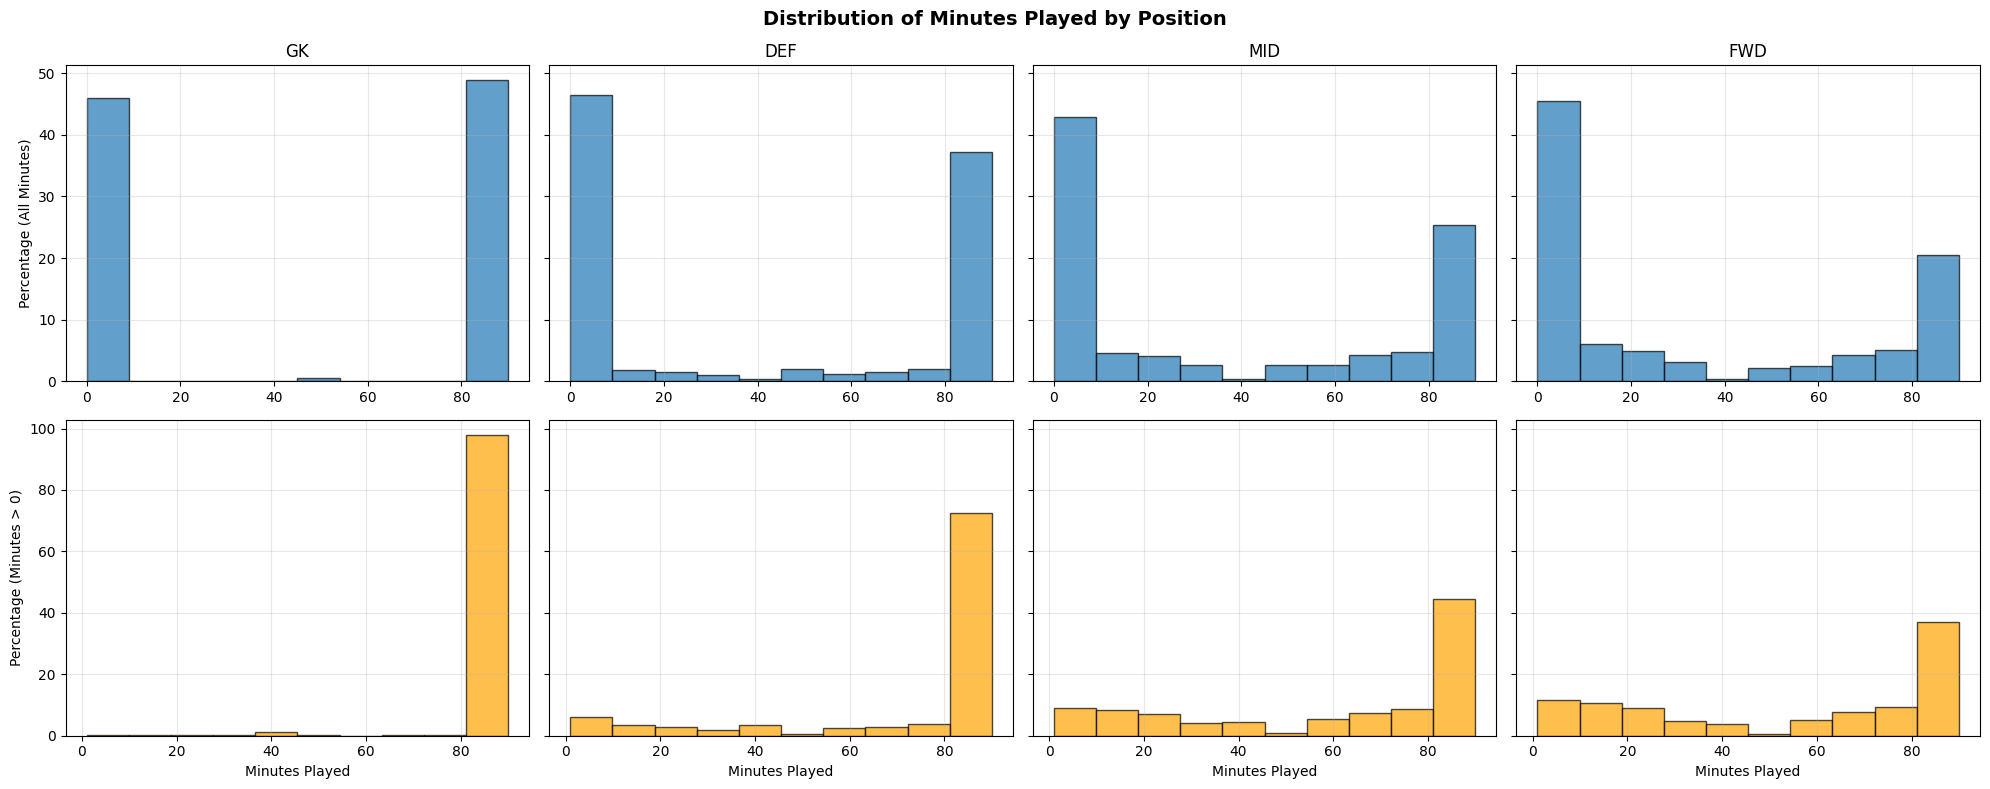

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.356


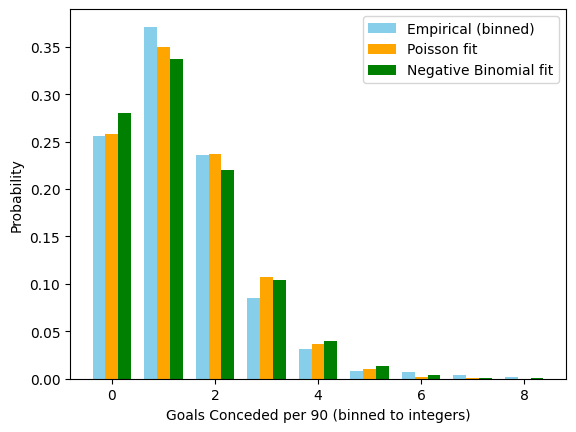

Mean: 1.347, Variance: 1.511
Overdispersion ratio (Var/Mean): 1.122
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.258


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.241


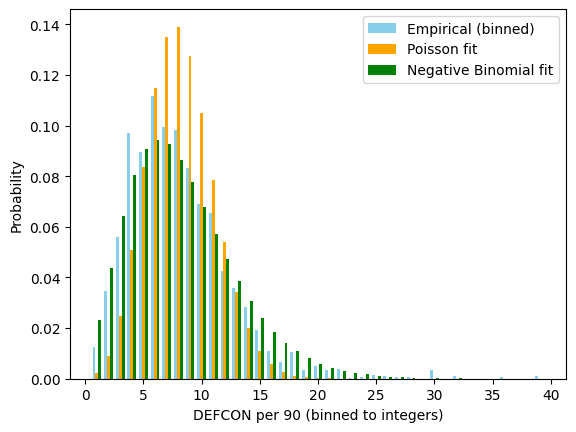

Mean: 8.233, Variance: 21.337
Overdispersion ratio (Var/Mean): 2.592
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [21]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.201


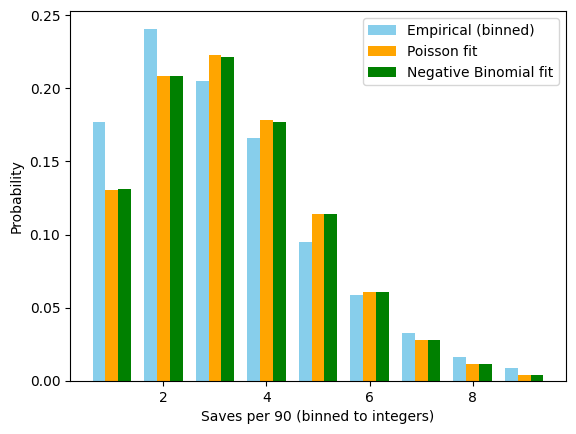

Mean: 3.201, Variance: 3.230
Overdispersion ratio (Var/Mean): 1.009
✅ Poisson assumption looks reasonable.


In [22]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [23]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [24]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [25]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    5551.000000
mean       60.297226
std        19.726748
min        13.775349
25%        42.421958
50%        59.988682
75%        79.031497
max        89.971419
Name: mins_pred, dtype: float64

In [26]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    5205.000000
mean        0.165779
std         0.151230
min         0.027079
25%         0.057605
50%         0.123050
75%         0.208926
max         0.879668
Name: xgp90_pred, dtype: float64

In [27]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    5205.000000
mean        0.097048
std         0.060466
min         0.030540
25%         0.049801
50%         0.079866
75%         0.124549
max         0.440407
Name: xap90_pred, dtype: float64

In [28]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    5551.000000
mean        1.432253
std         0.354019
min         0.480113
25%         1.168531
50%         1.420953
75%         1.685014
max         2.962279
Name: xgcp90_pred, dtype: float64

In [29]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    5551.000000
mean       15.642120
std         3.371419
min         5.230865
25%        13.418753
50%        15.318219
75%        17.528883
max        40.263900
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.459e+04
Date:                Tue, 24 Feb 2026   Prob (F-statistic):                        0.00
Time:                        10:14:30   Log-Likelihood:                         -40167.
No. Observations:               42636   AIC:                                  8.034e+04
Df Residuals:                   42635   BIC:                                  8.034e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

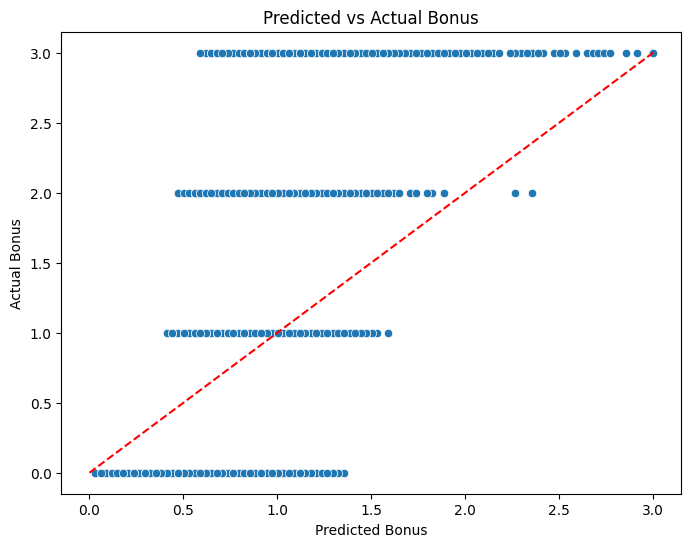

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459109  0.228820  1.105793  1.946977
FWD           0.331828  0.197275  1.046448  1.707982
GK            0.488363  0.244377  1.114712  2.005796
GKP                NaN       NaN       NaN       NaN
MID           0.396769  0.245101  1.049154  1.824511


C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [30]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [31]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [32]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    346.000000
mean       3.230213
std        0.672771
min        1.372088
25%        2.729527
50%        3.196584
75%        3.634226
max        5.613002
Name: xsavesp90_pred, dtype: float64

In [33]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    5205.000000
mean        7.965981
std         1.741534
min         2.910389
25%         6.838727
50%         8.212157
75%         9.179946
max        12.960846
Name: xdefconp90_pred, dtype: float64

In [34]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
130011,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,30.0,Man City,1234.624437,28.803006,0.133616,0.116552,1.718047
130013,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,31.0,Aston Villa,1163.658193,29.245672,0.137315,0.117127,1.663408
130015,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,32.0,Wolves,909.530755,28.696698,0.166160,0.120005,1.092764
130023,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,33.0,Crystal Palace,1050.195320,28.845455,0.113153,0.119195,1.750760
130025,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,34.0,Everton,1052.379469,28.845455,0.113153,0.112795,1.744710


In [35]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
144228,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,28.0,Man Utd,1105.197224,26.646094,0.847500,0.300658,1.828596
146724,Saša Kalajdžić,656.0,49.0,Wolves,FWD,20252026.0,28.0,Aston Villa,1163.658193,33.602720,0.844753,0.231810,2.443334
132387,Callum Marshall,626.0,43.0,West Ham,FWD,20252026.0,28.0,Liverpool,1180.732870,41.981958,0.842731,0.230805,2.146772
143870,Niclas Füllkrug,625.0,56.0,West Ham,FWD,20252026.0,28.0,Liverpool,1180.732870,35.694016,0.820730,0.244933,2.098781
132339,Chris Wood,525.0,72.0,Nott'm Forest,FWD,20252026.0,28.0,Brighton,1068.385456,34.653707,0.811783,0.286012,1.400551
130357,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,28.0,West Ham,980.204688,31.326968,0.754049,0.356737,1.646469
141657,Marc Guiu Paz,252.0,42.0,Chelsea,FWD,20252026.0,28.0,Arsenal,1241.419164,43.959678,0.741400,0.273689,2.286726
135632,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,28.0,Burnley,897.067666,43.009819,0.720449,0.281301,1.460973
147090,Stefanos Tzimas,180.0,52.0,Brighton,FWD,20252026.0,28.0,Nott'm Forest,1011.312737,36.777111,0.656921,0.263739,1.479007
146110,Romain Esse,269.0,47.0,Crystal Palace,MID,20252026.0,28.0,Man Utd,1105.197224,37.097257,0.614368,0.159132,1.962679


In [36]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [37]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [38]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_17672\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [39]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [40]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5551 entries, 0 to 5550
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          5551 non-null   object 
 1   team_name               5551 non-null   object 
 2   team_elo                5551 non-null   float64
 3   element                 5551 non-null   float64
 4   position                5551 non-null   object 
 5   opp_team_name           5551 non-null   object 
 6   opp_team_elo            5551 non-null   float64
 7   season                  5551 non-null   float64
 8   value                   5551 non-null   float64
 9   event                   5551 non-null   float64
 10  mins_pred               5551 non-null   float64
 11  xgp90_pred              5205 non-null   float64
 12  xap90_pred              5205 non-null   float64
 13  xgcp90_pred             5551 non-null   float64
 14  xpoints_mins            5551 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
print(f"Gameweek {current_gw+1} Predictions")
prediction_data[
    prediction_data['event']==current_gw+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 28 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
139594,Joško Gvardiol,403.0,28.0,59.0,Man City,DEF,Leeds,992.544604,60.822811,1.520559,0.942437,0.136848,1.898510,0.0,-0.178930,0.544039,0.623366,5.486827
144023,Nico O'Reilly,411.0,28.0,49.0,Man City,DEF,Leeds,992.544604,81.821865,1.898638,0.445609,0.186362,1.852102,0.0,-0.188585,0.544039,0.648820,5.386986
142311,Matheus Nunes,407.0,28.0,54.0,Man City,DEF,Leeds,992.544604,81.899010,1.899339,0.218859,0.188075,1.972894,0.0,-0.164214,0.544039,0.627951,5.286943
131049,Antoine Semenyo,82.0,28.0,80.0,Man City,MID,Leeds,992.544604,85.477379,1.927421,1.253029,0.541451,0.451549,0.0,0.000000,0.512498,0.586889,5.272837
129939,Abdukodir Khusanov,406.0,28.0,54.0,Man City,DEF,Leeds,992.544604,74.512559,1.810192,0.203149,0.135013,2.073915,0.0,-0.145633,0.544039,0.573560,5.194234
148281,Viktor Gyökeres,666.0,28.0,88.0,Arsenal,FWD,Chelsea,1132.600027,78.726555,1.866765,2.078675,0.355541,0.000000,0.0,0.000000,0.259417,0.588877,5.149275
142449,Max Alleyne,794.0,28.0,41.0,Man City,DEF,Leeds,992.544604,62.580900,1.564167,0.635064,0.111756,1.846083,0.0,-0.189864,0.544039,0.618959,5.130203
132313,Bruno Guimarães Rodriguez Moura,488.0,28.0,69.0,Newcastle,MID,Everton,1052.379469,80.611856,1.887073,1.250128,0.564351,0.301603,0.0,0.000000,0.512498,0.599980,5.115632
141773,Marc Guéhi,260.0,28.0,52.0,Man City,DEF,Leeds,992.544604,85.189603,1.925460,0.243708,0.150213,1.812109,0.0,-0.197210,0.544039,0.612813,5.091133
133071,Conor Bradley,375.0,28.0,49.0,Liverpool,DEF,West Ham,980.204688,64.393646,1.608108,0.643744,0.403186,1.491957,0.0,-0.277883,0.544039,0.674542,5.087693


In [44]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (prediction_data['event']>=current_gw)&(prediction_data['event']<=current_gw+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW28 - GW32


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
65,Bruno Guimarães Rodriguez Moura,403.059279,9.435365,6.077614,2.737146,1.449665,0.0,0.000000,2.562488,3.046866,25.309144
86,Conor Bradley,322.418231,8.051208,3.210951,1.731500,7.166346,0.0,-1.481360,2.720194,3.282392,24.681231
134,Enzo Fernández,422.066980,9.599629,5.611103,2.856198,0.903712,0.0,0.000000,2.562488,2.673117,24.206247
357,Mohamed Salah,391.795375,9.312275,5.742165,2.109157,1.859496,0.0,0.000000,2.562488,2.613732,24.199313
185,Ibrahima Konaté,434.571978,9.682598,1.208851,0.698504,7.993395,0.0,-1.244769,2.720194,2.973853,24.032626
64,Bruno Borges Fernandes,421.293650,9.593895,5.029640,2.735567,1.260900,0.0,0.000000,2.562488,2.794032,23.976523
15,Alexis Mac Allister,396.556727,9.366875,4.993562,2.344054,1.901532,0.0,0.000000,2.562488,2.790995,23.959506
156,Fábio Freitas Gouveia Carvalho,209.776557,5.707902,9.667803,1.773693,0.903096,0.0,0.000000,2.562488,3.124215,23.739195
152,Florian Wirtz,409.288887,9.494823,4.141922,2.710727,1.909146,0.0,0.000000,2.562488,2.875990,23.695095
491,Virgil van Dijk,398.398841,9.386968,1.353770,0.660470,7.758772,0.0,-1.305720,2.720194,3.008828,23.583281


In [45]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
65,Bruno Guimarães Rodriguez Moura,886.419616,20.754652,13.450862,6.251487,3.208856,0.0,0.000000,5.637474,6.655978,55.959309
134,Enzo Fernández,928.606287,21.119618,12.508722,6.702573,2.325207,0.0,0.000000,5.637474,6.028740,54.322334
490,Viktor Gyökeres,786.565068,18.659016,22.000265,3.873833,0.000000,0.0,0.000000,2.594174,6.174188,53.301476
64,Bruno Borges Fernandes,926.846030,21.106570,11.018551,5.829969,2.841937,0.0,0.000000,5.637474,6.231231,52.665733
86,Conor Bradley,708.827692,17.700980,7.148826,3.377436,14.696046,0.0,-3.620646,5.984426,6.703916,51.990985
156,Fábio Freitas Gouveia Carvalho,457.396640,12.507422,21.549231,3.515348,1.842916,0.0,0.000000,5.637474,6.718788,51.771179
357,Mohamed Salah,862.166688,20.489624,12.070172,4.467037,3.561884,0.0,0.000000,5.637474,5.492174,51.718366
185,Ibrahima Konaté,956.058351,21.301716,2.635465,1.467688,17.035289,0.0,-2.887977,5.984426,6.177366,51.713973
32,Antoine Semenyo,854.441081,19.271956,12.457921,5.238342,3.595810,0.0,0.000000,5.124976,5.698990,51.387995
15,Alexis Mac Allister,871.634102,20.598250,10.873680,4.802183,3.535655,0.0,0.000000,5.637474,5.883833,51.331075


In [46]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [47]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [48]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [49]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 5551 new predictions to predictions_allgws


In [50]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points
74498,Erling Haaland,28.0,20252026.0,NaN
80059,Erling Haaland,28.0,20252026.0,NaN
85599,Erling Haaland,28.0,20252026.0,NaN


In [51]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
182065,Erling Haaland,13.0,20252026.0,2.0,90.0
182066,Erling Haaland,14.0,20252026.0,14.0,90.0
182067,Erling Haaland,15.0,20252026.0,2.0,68.0
182068,Erling Haaland,16.0,20252026.0,13.0,90.0
182069,Erling Haaland,17.0,20252026.0,16.0,90.0
182070,Erling Haaland,18.0,20252026.0,2.0,90.0
182071,Erling Haaland,19.0,20252026.0,2.0,90.0
182072,Erling Haaland,20.0,20252026.0,2.0,90.0
182073,Erling Haaland,21.0,20252026.0,6.0,90.0
182074,Erling Haaland,22.0,20252026.0,2.0,79.0


In [52]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
59832,Erling Haaland,2026-02-19 17:56:20.307174,38.0,4.421420,NaN
77213,Erling Haaland,2026-02-23 12:07:30.733847,38.0,4.533205,NaN
65863,Erling Haaland,2026-02-20 10:52:25.776847,38.0,4.434418,NaN
71670,Erling Haaland,2026-02-22 11:15:02.719357,38.0,4.363917,NaN


In [53]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 27.0   3.437517
                                                          28.0   3.421395
                                                          29.0   3.392790
                                                          30.0   3.432445
                                                          31.0   3.432435
...                                                                   ...
2026-02-24 10:14:37.233826 27                  20252026.0 28.0   3.385579
                                                          29.0   3.401298
                                                          30.0   3.431937
                                                          31.0   3.391655
                                                          32.0   3.435978

[99 rows x 1 columns]

In [54]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [55]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [56]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==25)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points


In [57]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,29.500000
min,2026-01-07 16:29:20.849190,27.000000
25%,2026-01-07 16:29:20.849189888,28.000000
50%,2026-01-08 04:37:05.395073024,29.500000
75%,2026-01-08 16:44:49.940955904,31.000000
max,2026-01-08 16:44:49.940956,32.000000
std,NaN,1.744557


In [58]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [59]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 33.61 minute(s)


In [60]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)